Data Acquisition

In [1]:
#  Mount Drive
from google.colab import drive, userdata
import os, json

drive.mount('/content/drive')

# Setup Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({
        "username": userdata.get('KAGGLE_USERNAME'),
        "key": userdata.get('KAGGLE_KEY')
    }, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
!pip install -q kaggle

# Download thẳng vào Drive
!mkdir -p '/content/drive/MyDrive/team_data'
!kaggle datasets download -d arashnic/book-recommendation-dataset \
    -p '/content/drive/MyDrive/team_data' \
    --unzip --force

print("Done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


SecretNotFoundError: Secret KAGGLE_USERNAME does not exist.

Data Inspection

In [2]:
import pandas as pd
import numpy as np
DATA_PATH = '/content/drive/MyDrive/team_data/'

In [3]:
# Check encoding
import chardet
for filename in ['Books.csv', 'Users.csv', 'Ratings.csv']:
    with open(DATA_PATH + filename, 'rb') as f:
        result = chardet.detect(f.read(100000)) #đọc 100kb đầu
        print(f"{filename}: {result}")

Books.csv: {'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}
Users.csv: {'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}
Ratings.csv: {'encoding': 'ascii', 'confidence': 1.0, 'language': ''}


In [4]:
books   = pd.read_csv(DATA_PATH + 'Books.csv')
users   = pd.read_csv(DATA_PATH + 'Users.csv')
ratings = pd.read_csv(DATA_PATH + 'Ratings.csv')
print("File loaded successfully")

/tmp/ipykernel_5095/4025410421.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books   = pd.read_csv(DATA_PATH + 'Books.csv')


File loaded successfully


In [5]:
#Check for consistency
for name, df in [('Books', books), ('Users', users), ('Ratings', ratings)]:
    print(f"{name}.csv")
    print(f"   Number of rows : {df.shape[0]:,}")
    print(f"   Number of columns  : {df.shape[1]}")
    print(f"   Column name : {list(df.columns)}")

Books.csv
   Number of rows : 271,360
   Number of columns  : 8
   Column name : ['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']
Users.csv
   Number of rows : 278,858
   Number of columns  : 3
   Column name : ['User-ID', 'Location', 'Age']
Ratings.csv
   Number of rows : 1,149,780
   Number of columns  : 3
   Column name : ['User-ID', 'ISBN', 'Book-Rating']


In [6]:
print(f"Books   : {books.shape}")
print(f"Users   : {users.shape}")
print(f"Ratings : {ratings.shape}")

Books   : (271360, 8)
Users   : (278858, 3)
Ratings : (1149780, 3)


In [7]:
# Identify relationships
# Tìm các cột chung giữa các file (Primary Key / Foreign Key)
print("Common columns between Users & Ratings :", set(users.columns) & set(ratings.columns))
print("Common columns between Books & Users   :", set(books.columns) & set(users.columns))
print("Common columns between Books & Ratings :", set(books.columns) & set(ratings.columns))

# Kiểm tra số lượng ISBN khớp giữa Books và Ratings
isbn_books   = set(books['ISBN'].unique())
isbn_ratings = set(ratings['ISBN'].unique())

print("\n=== ISBN Matching ===")
print(f"Total ISBN in Books     : {len(isbn_books):,}")
print(f"Total ISBN in Ratings   : {len(isbn_ratings):,}")
print(f"Matched ISBN            : {len(isbn_books & isbn_ratings):,}")
print(f"Missing in Books        : {len(isbn_ratings - isbn_books):,}")

# Kiểm tra số lượng User-ID khớp giữa Users và Ratings
uid_users   = set(users['User-ID'].unique())
uid_ratings = set(ratings['User-ID'].unique())

print("\n=== User-ID Matching ===")
print(f"Total Users             : {len(uid_users):,}")
print(f"Total Users in Ratings  : {len(uid_ratings):,}")
print(f"Matched Users           : {len(uid_users & uid_ratings):,}")
print(f"Missing in Users        : {len(uid_ratings - uid_users):,}")

Common columns between Users & Ratings : {'User-ID'}
Common columns between Books & Users   : set()
Common columns between Books & Ratings : {'ISBN'}

=== ISBN Matching ===
Total ISBN in Books     : 271,360
Total ISBN in Ratings   : 340,556
Matched ISBN            : 270,151
Missing in Books        : 70,405

=== User-ID Matching ===
Total Users             : 278,858
Total Users in Ratings  : 105,283
Matched Users           : 105,283
Missing in Users        : 0


In [8]:
# Tổng hợp thông tin kiểu dữ liệu và missing values từng file
for name, df in [('Books', books), ('Users', users), ('Ratings', ratings)]:
    print(f"\n {name}.csv")
    summary = pd.DataFrame({
        'Dtype'         : df.dtypes,
        'Non-Null Count': df.notnull().sum(),
        'Missing Count' : df.isnull().sum(),
        'Missing %'     : (df.isnull().sum() / len(df) * 100).round(2)
    })
    print(summary)


 Books.csv
                      Dtype  Non-Null Count  Missing Count  Missing %
ISBN                 object          271360              0        0.0
Book-Title           object          271360              0        0.0
Book-Author          object          271358              2        0.0
Year-Of-Publication  object          271360              0        0.0
Publisher            object          271358              2        0.0
Image-URL-S          object          271360              0        0.0
Image-URL-M          object          271360              0        0.0
Image-URL-L          object          271357              3        0.0

 Users.csv
            Dtype  Non-Null Count  Missing Count  Missing %
User-ID     int64          278858              0       0.00
Location   object          278858              0       0.00
Age       float64          168096         110762      39.72

 Ratings.csv
              Dtype  Non-Null Count  Missing Count  Missing %
User-ID       int64         11

Data Loading and Cleaning


In [9]:
# Xử lý bảng Books
# Xóa các cột URL hình ảnh không cần thiết cho mô hình
books = books.drop(columns=['Image-URL-S', 'Image-URL-M', 'Image-URL-L'])

# Chuyển năm
books['Year-Of-Publication'] = pd.to_numeric(
    books['Year-Of-Publication'], errors='coerce')

#Lọc giữ lại nhưng năm hợp lệ
books.loc[
    (books['Year-Of-Publication'] < 1800) |
    (books['Year-Of-Publication'] > 2004), # đây là dataset lấy năm 2004 nên max là 2004
    'Year-Of-Publication'
] = None

# Fill giá trị thiếu
books['Year-Of-Publication'] = books['Year-Of-Publication'].fillna(
    books['Year-Of-Publication'].median()
)
books['Book-Author'] = books['Book-Author'].fillna('Unknown')
books['Publisher'] = books['Publisher'].fillna('Unknown')

# Xóa hàng trùng lặp
books = books.drop_duplicates(subset='ISBN')

print(f"Books cleaned: {books.shape}")

Books cleaned: (271360, 5)


In [10]:
# Xử lý bảng Users
# Chuyển tuổi về kiểu số, lỗi sẽ thành NaN
users['Age'] = pd.to_numeric(users['Age'], errors='coerce')

# Đặt NaN cho các giá trị tuổi không hợp lệ (< 5 hoặc > 100)
users.loc[(users['Age'] < 5) | (users['Age'] > 100), 'Age'] = np.nan

# Điền median cho các giá trị tuổi bị thiếu
users['Age'].fillna(users['Age'].median(), inplace=True)

# Tách cột Location thành City, State, Country
users[['City', 'State', 'Country']] = (
    users['Location'].str.split(',', n=2, expand=True))

# Chuẩn hóa tên quốc gia về chữ thường
users['Country'] = users['Country'].str.strip().str.lower()

# Xóa các hàng trùng lặp theo User-ID
users.drop_duplicates(subset='User-ID', inplace=True)

print(f"Users cleaned: {users.shape}")

/tmp/ipykernel_5095/2842196471.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  users['Age'].fillna(users['Age'].median(), inplace=True)


Users cleaned: (278858, 6)


In [11]:
# Xử lý Ratings
# Chỉ giữ explicit ratings (1–10), bỏ implicit (0)
ratings_explicit = ratings[ratings['Book-Rating'] > 0].copy() #0 không phải rating thật -> loại bỏ
ratings_explicit = ratings_explicit.drop_duplicates()
print(f"After drop_duplicates: {len(ratings_explicit):,}")

print(f"Original ratings     : {len(ratings):,}")
print(f"Explicit ratings     : {len(ratings_explicit):,}")
print(f"Implicit removed (0) : {len(ratings) - len(ratings_explicit):,}")

After drop_duplicates: 433,671
Original ratings     : 1,149,780
Explicit ratings     : 433,671
Implicit removed (0) : 716,109


In [12]:
# Merging
print(" MERGING")

# 1: Ratings ← merge → Books (theo ISBN)
df = ratings_explicit.merge(books, on='ISBN', how='inner')
print(f"After merging Ratings + Books : {df.shape}")

# 2: df ← merge → Users (theo User-ID)
df = df.merge(users, on='User-ID', how='inner')
print(f"After merge + Users: {df.shape}")

# Kiểm tra missing sau merge
print(f"Missing values sau merge:")
print(df.isnull().sum())

# Xóa NaN còn sót
df.dropna(inplace=True)
# ── Lưu file cleaned để Feature Engineering đọc lại ──────────
save_path = DATA_PATH + 'data_clean_merged.csv'
df.to_csv(save_path, index=False)
print(f"✓ Saved: {save_path}")
print(f"  Shape : {df.shape}")
print(f"  Size  : {os.path.getsize(save_path) / 1024 / 1024:.1f} MB")
print(f"Final shape: {df.shape}")
print(df.head(3))

 MERGING
After merging Ratings + Books : (383842, 7)
After merge + Users: (383842, 12)
Missing values sau merge:
User-ID                0
ISBN                   0
Book-Rating            0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Location               0
Age                    0
City                   0
State                  0
Country                0
dtype: int64
✓ Saved: /content/drive/MyDrive/team_data/data_clean_merged.csv
  Shape : (383842, 12)
  Size  : 54.9 MB
Final shape: (383842, 12)
   User-ID        ISBN  Book-Rating  \
0   276726  0155061224            5   
1   276729  052165615X            3   
2   276729  0521795028            6   

                                          Book-Title    Book-Author  \
0                                   Rites of Passage     Judith Rae   
1                                     Help!: Level 1  Philip Prowse   
2  The Amsterdam Connection : Level 4 (Cambridge ...    Sue Leather   

 

In [13]:
# Xóa duplicate
# Chỉ giữ lại bản ghi cuối cùng nếu một User đánh giá cùng 1 cuốn sách nhiều lần
df.drop_duplicates(subset=['User-ID', 'ISBN'], keep='last', inplace=True)
# Đảm bảo các cột số có đúng kiểu dữ liệu
df['Year-Of-Publication'] = df['Year-Of-Publication'].astype(int)
df['Age']                 = df['Age'].astype(int)
df['Book-Rating']         = df['Book-Rating'].astype(int)
df['User-ID']             = df['User-ID'].astype(int)
# Kiểm tra lại kiểu dữ liệu sau chuẩn hóa
print("Data types after cleaning:")
print(df.dtypes)

Data types after cleaning:
User-ID                 int64
ISBN                   object
Book-Rating             int64
Book-Title             object
Book-Author            object
Year-Of-Publication     int64
Publisher              object
Location               object
Age                     int64
City                   object
State                  object
Country                object
dtype: object


Exploratory Data Analysis

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style chung cho tất cả biểu đồ
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.titlepad'    : 12,
    'font.family'      : 'DejaVu Sans',
    })

In [15]:
# In thống kê mô tả các cột số
print("Descriptive Statistics Overview")
print(df.describe().round(2))
# In thông tin tổng quan dataframe
print("\nDataFrame Information:")
print(df.info())

Descriptive Statistics Overview
         User-ID  Book-Rating  Year-Of-Publication        Age
count  383842.00    383842.00            383842.00  383842.00
mean   136031.46         7.63              1995.71      35.25
std     80482.30         1.84                 7.24      10.51
min         8.00         1.00              1806.00       5.00
25%     67591.00         7.00              1993.00      31.00
50%    133789.00         8.00              1997.00      32.00
75%    206219.00         9.00              2001.00      40.00
max    278854.00        10.00              2004.00     100.00

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383842 entries, 0 to 383841
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   User-ID              383842 non-null  int64 
 1   ISBN                 383842 non-null  object
 2   Book-Rating          383842 non-null  int64 
 3   Book-Title          

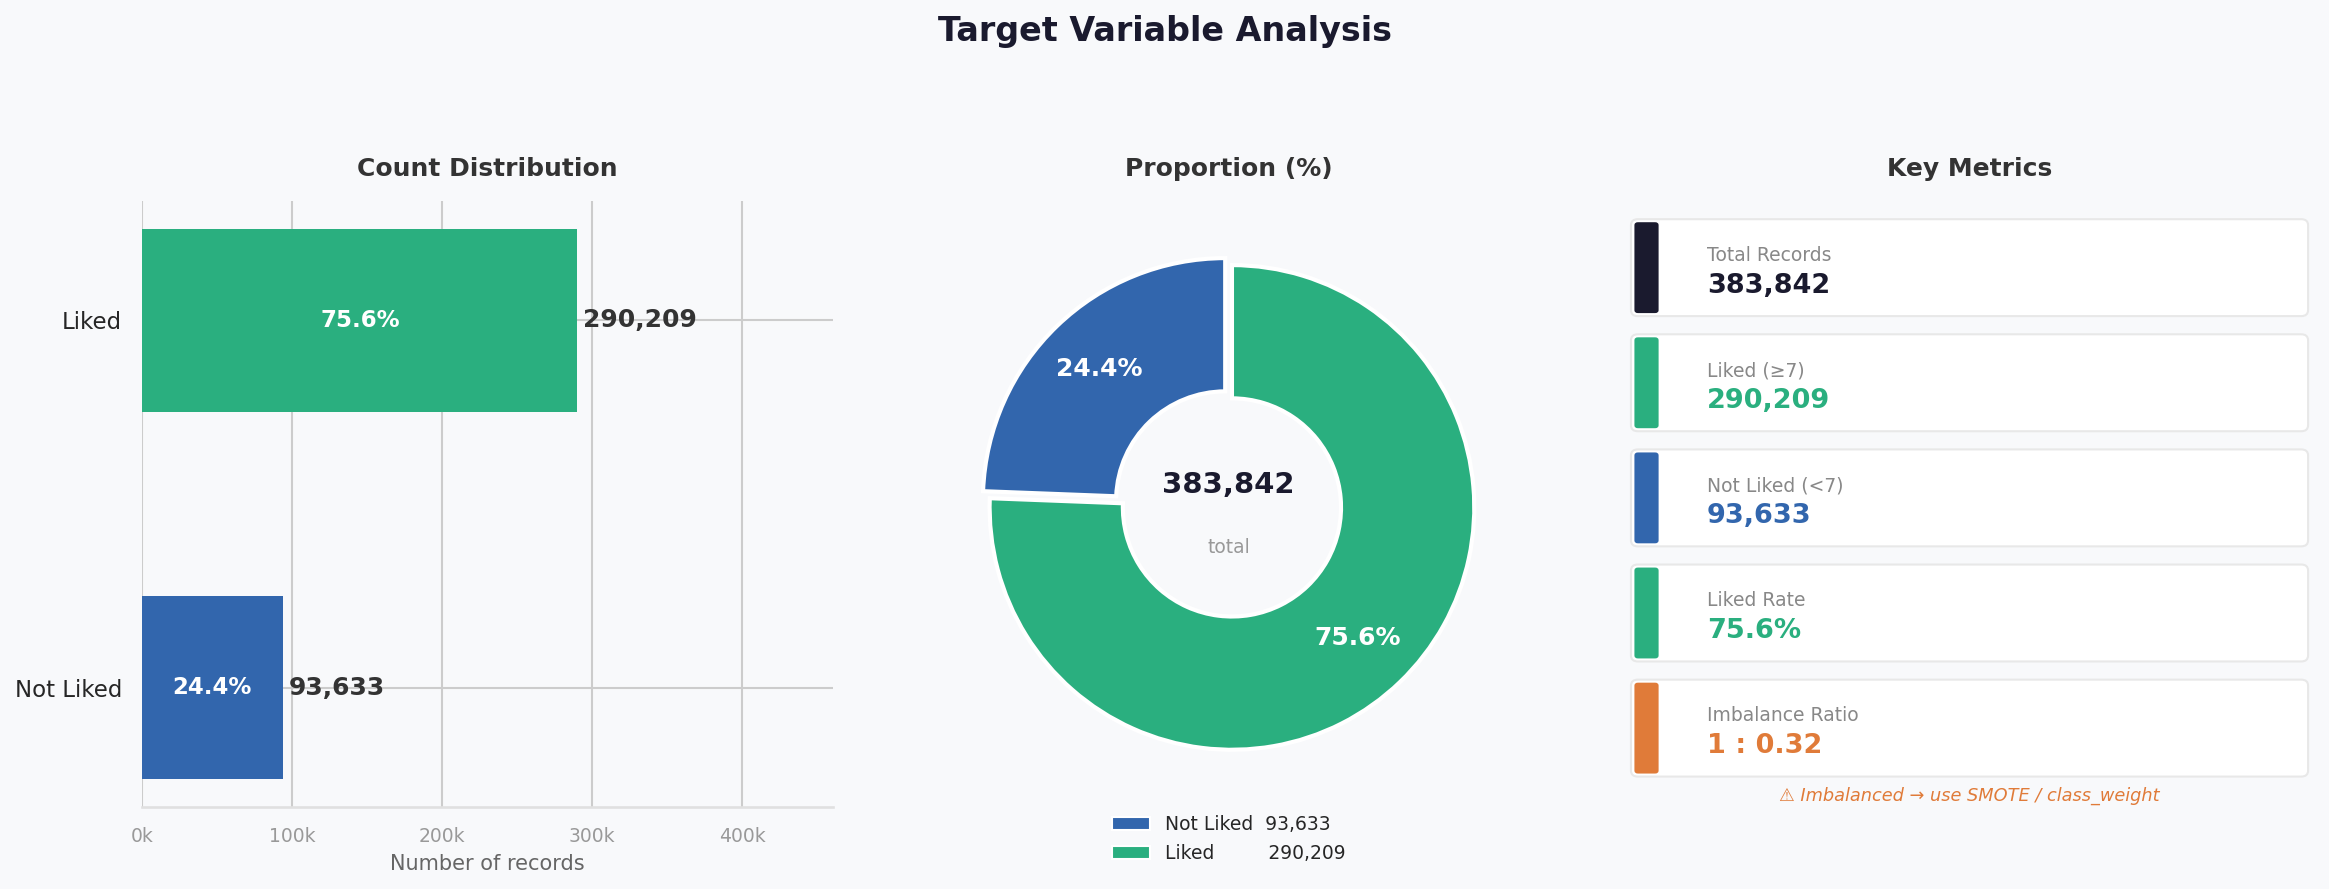

Liked     : 290,209  (75.6%)
Not Liked : 93,633 (24.4%)
Ratio     : 1 : 0.32
⚠ Imbalanced → use SMOTE / class_weight


In [16]:
# Target Variable Creation & Imbalance Analysis
# Tạo nhãn phân loại: Rating >= 7 → Liked (1), còn lại → Not Liked (0)
df['Liked'] = (df['Book-Rating'] >= 7).astype(int)

# Tính toán số liệu
total    = len(df)
liked    = df['Liked'].sum()
notliked = total - liked
ratio    = liked / notliked

counts = df['Liked'].value_counts().sort_index()

# Import mpatches for custom legend elements
import matplotlib.patches as mpatches

#  Màu sắc
COLOR_NOT = '#3266AD'
COLOR_YES = '#2AAF7F'
BG        = '#F8F9FB'

fig = plt.figure(figsize=(16, 6), facecolor=BG)
fig.suptitle('Target Variable Analysis', fontsize=16,
             fontweight='bold', y=1.01, color='#1a1a2e')

#  Layout: 3 cột
ax1 = fig.add_subplot(1, 3, 1)   # bar chart
ax2 = fig.add_subplot(1, 3, 2)   # donut chart
ax3 = fig.add_subplot(1, 3, 3)   # metric cards

# BIỂU ĐỒ 1: Horizontal bar chart đẹp hơn
ax1.set_facecolor(BG)
ax1.spines[['top','right','left']].set_visible(False)
ax1.spines['bottom'].set_color('#e0e0e0')

bars = ax1.barh(
    ['Not Liked', 'Liked'],
    [notliked, liked],
    color=[COLOR_NOT, COLOR_YES],
    height=0.5,
    edgecolor='none'
)

# Thêm giá trị vào cuối thanh
for bar, val in zip(bars, [notliked, liked]):
    ax1.text(
        bar.get_width() + total * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        va='center', ha='left',
        fontsize=12, fontweight='bold',
        color='#333333'
    )

# Thêm % vào trong thanh
for bar, pct in zip(bars, [notliked/total*100, liked/total*100]):
    ax1.text(
        bar.get_width() * 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%',
        va='center', ha='center',
        fontsize=11, color='white', fontweight='bold'
    )

ax1.set_xlim(0, total * 1.2)
ax1.set_xlabel('Number of records', fontsize=10, color='#666666')
ax1.set_title('Count Distribution', fontsize=12,
              fontweight='bold', pad=12, color='#333333')
ax1.tick_params(axis='y', labelsize=11)
ax1.tick_params(axis='x', colors='#999999', labelsize=9)
ax1.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax1.set_facecolor(BG)

# BIỂU ĐỒ 2: Donut chart với text ở giữa
ax2.set_facecolor(BG)

wedges, texts, autotexts = ax2.pie(
    [notliked, liked],
    colors=[COLOR_NOT, COLOR_YES],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    explode=(0.02, 0.02)
)

for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')

# Text ở giữa donut
ax2.text(0, 0.08, f'{total:,}', ha='center', va='center',
         fontsize=14, fontweight='bold', color='#1a1a2e')
ax2.text(0, -0.18, 'total', ha='center', va='center',
         fontsize=9, color='#999999')

ax2.set_title('Proportion (%)', fontsize=12,
              fontweight='bold', pad=12, color='#333333')

legend_elements = [
    mpatches.Patch(facecolor=COLOR_NOT, label=f'Not Liked  {notliked:,}'),
    mpatches.Patch(facecolor=COLOR_YES, label=f'Liked         {liked:,}')
]
ax2.legend(handles=legend_elements, loc='lower center',
           bbox_to_anchor=(0.5, -0.12), ncol=1,
           fontsize=9, frameon=False)

# BIỂU ĐỒ 3: Metric summary cards
ax3.set_facecolor(BG)
ax3.axis('off')
ax3.set_title('Key Metrics', fontsize=12,
              fontweight='bold', pad=12, color='#333333')

metrics = [
    ('Total Records',   f'{total:,}',           '#1a1a2e'),
    ('Liked (≥7)',      f'{liked:,}',            COLOR_YES),
    ('Not Liked (<7)',  f'{notliked:,}',         COLOR_NOT),
    ('Liked Rate',      f'{liked/total*100:.1f}%', COLOR_YES),
    ('Imbalance Ratio', f'1 : {1/ratio:.2f}',   '#E07B39'),
]

for i, (label, value, color) in enumerate(metrics):
    y = 0.88 - i * 0.19

    # Card background
    fancy = mpatches.FancyBboxPatch(
        (0.02, y - 0.06), 0.96, 0.14,
        boxstyle='round,pad=0.01',
        facecolor='white',
        edgecolor='#e8e8e8',
        linewidth=1,
        transform=ax3.transAxes,
        zorder=1
    )
    ax3.add_patch(fancy)

    # Thanh màu bên trái
    accent = mpatches.FancyBboxPatch(
        (0.02, y - 0.06), 0.025, 0.14,
        boxstyle='round,pad=0.005',
        facecolor=color,
        edgecolor='none',
        transform=ax3.transAxes,
        zorder=2
    )
    ax3.add_patch(accent)

    # Label
    ax3.text(0.12, y + 0.03, label,
             transform=ax3.transAxes,
             fontsize=9, color='#888888', va='center')

    # Value
    ax3.text(0.12, y - 0.02, value,
             transform=ax3.transAxes,
             fontsize=13, fontweight='bold',
             color=color, va='center')

# Nhận xét imbalance
note_color = '#E07B39' if (ratio < 0.4 or ratio > 2.5) else '#2AAF7F'
note_text  = ('⚠ Imbalanced → use SMOTE / class_weight'
              if (ratio < 0.4 or ratio > 2.5)
              else '✓ Data is relatively balanced')

ax3.text(0.5, 0.01, note_text,
         transform=ax3.transAxes,
         fontsize=8.5, color=note_color,
         ha='center', style='italic')

plt.tight_layout(pad=2.0)
plt.savefig('01_target_distribution.png',
            dpi=150, bbox_inches='tight',
            facecolor=BG)
plt.show()

# In kết quả
print(f"Liked     : {liked:,}  ({liked/total*100:.1f}%)")
print(f"Not Liked : {notliked:,} ({notliked/total*100:.1f}%)")
print(f"Ratio     : 1 : {1/ratio:.2f}")
print(note_text)

BOOK RATING ANALYSIS
Average rating : 7.63
Median rating   : 8.00
Most common rating   : 8


/tmp/ipykernel_5095/833165875.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


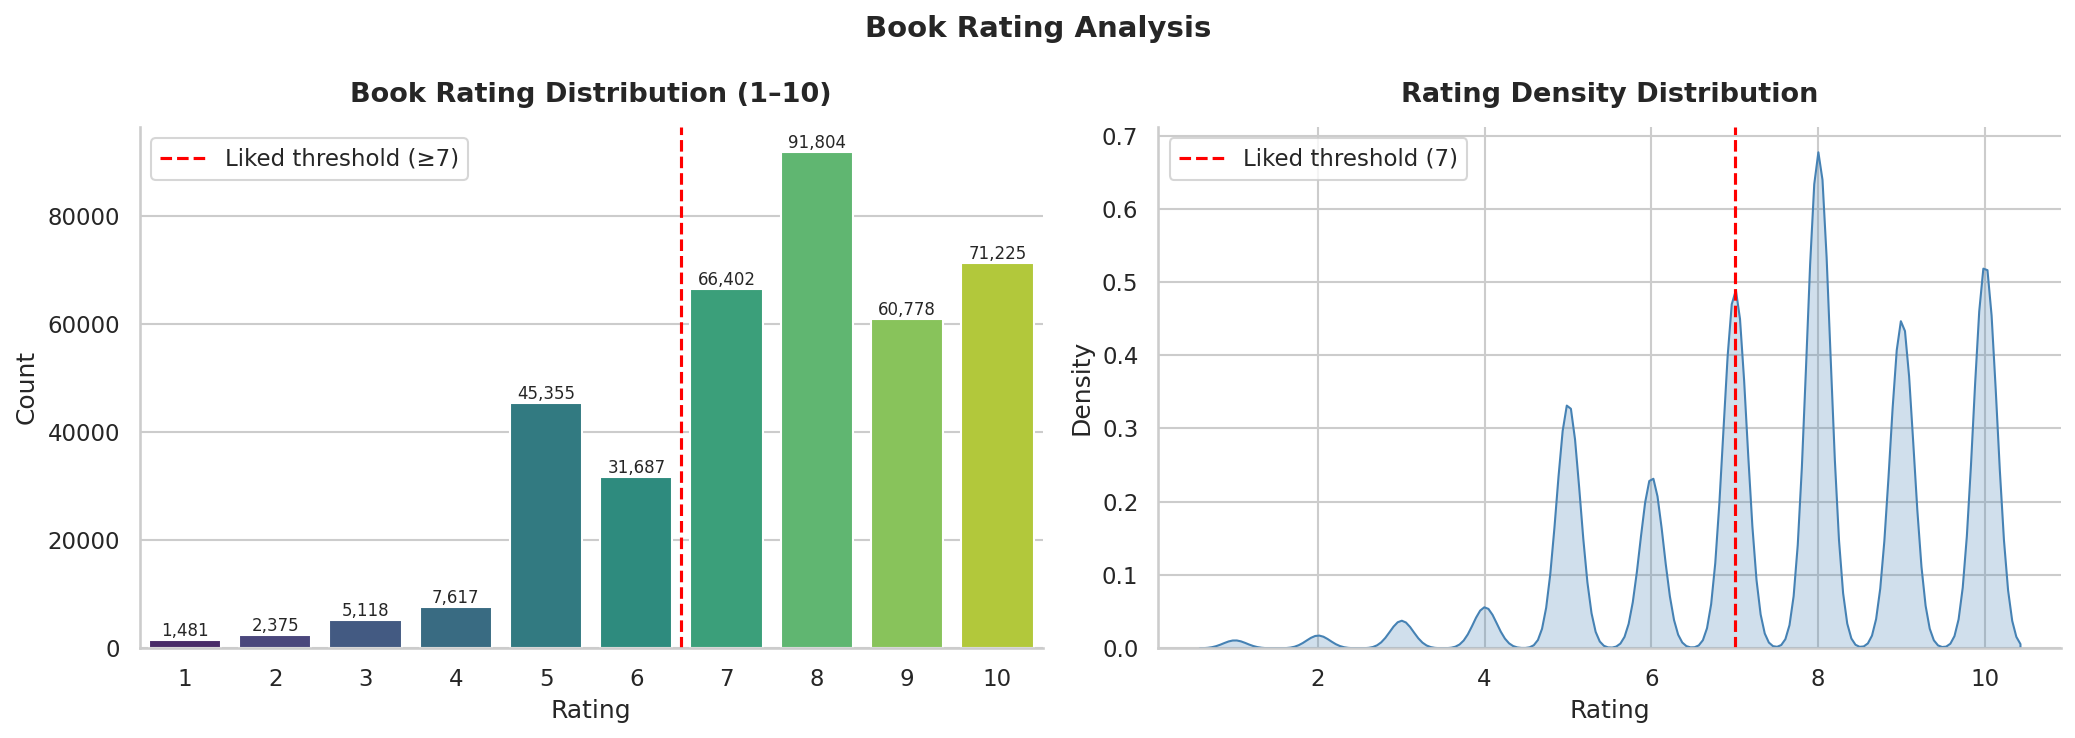

In [17]:
# Book Rating Analysis
print("BOOK RATING ANALYSIS")

# Thống kê rating
print(f"Average rating : {df['Book-Rating'].mean():.2f}")
print(f"Median rating   : {df['Book-Rating'].median():.2f}")
print(f"Most common rating   : {df['Book-Rating'].mode()[0]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ phân phối rating 1–10
rating_counts = df['Book-Rating'].value_counts().sort_index()
sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values,
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Book Rating Distribution (1–10)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Thêm số liệu lên cột
for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=8
    )

# Vẽ đường phân cách ngưỡng Liked (>= 7)
axes[0].axvline(x=5.5, color='red', linestyle='--', linewidth=1.5,
                label='Liked threshold (≥7)')
axes[0].legend()

# Biểu đồ KDE phân phối rating
sns.kdeplot(
    data=df, x='Book-Rating',
    fill=True, color='steelblue',
    ax=axes[1]
)
axes[1].set_title('Rating Density Distribution')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Density')
axes[1].axvline(x=7, color='red', linestyle='--',
                linewidth=1.5, label='Liked threshold (7)')
axes[1].legend()

plt.suptitle('Book Rating Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_rating_analysis.png', dpi=150)
plt.show()

USER ANALYSIS
Average age : 35.3
Median age   : 32.0
Minimum age   : 5
Maximum age   : 100


/tmp/ipykernel_5095/3640459663.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_age = df.groupby('Age-Group')['Book-Rating'].mean().round(2)
/tmp/ipykernel_5095/3640459663.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5095/3640459663.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5095/3640459663.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to r

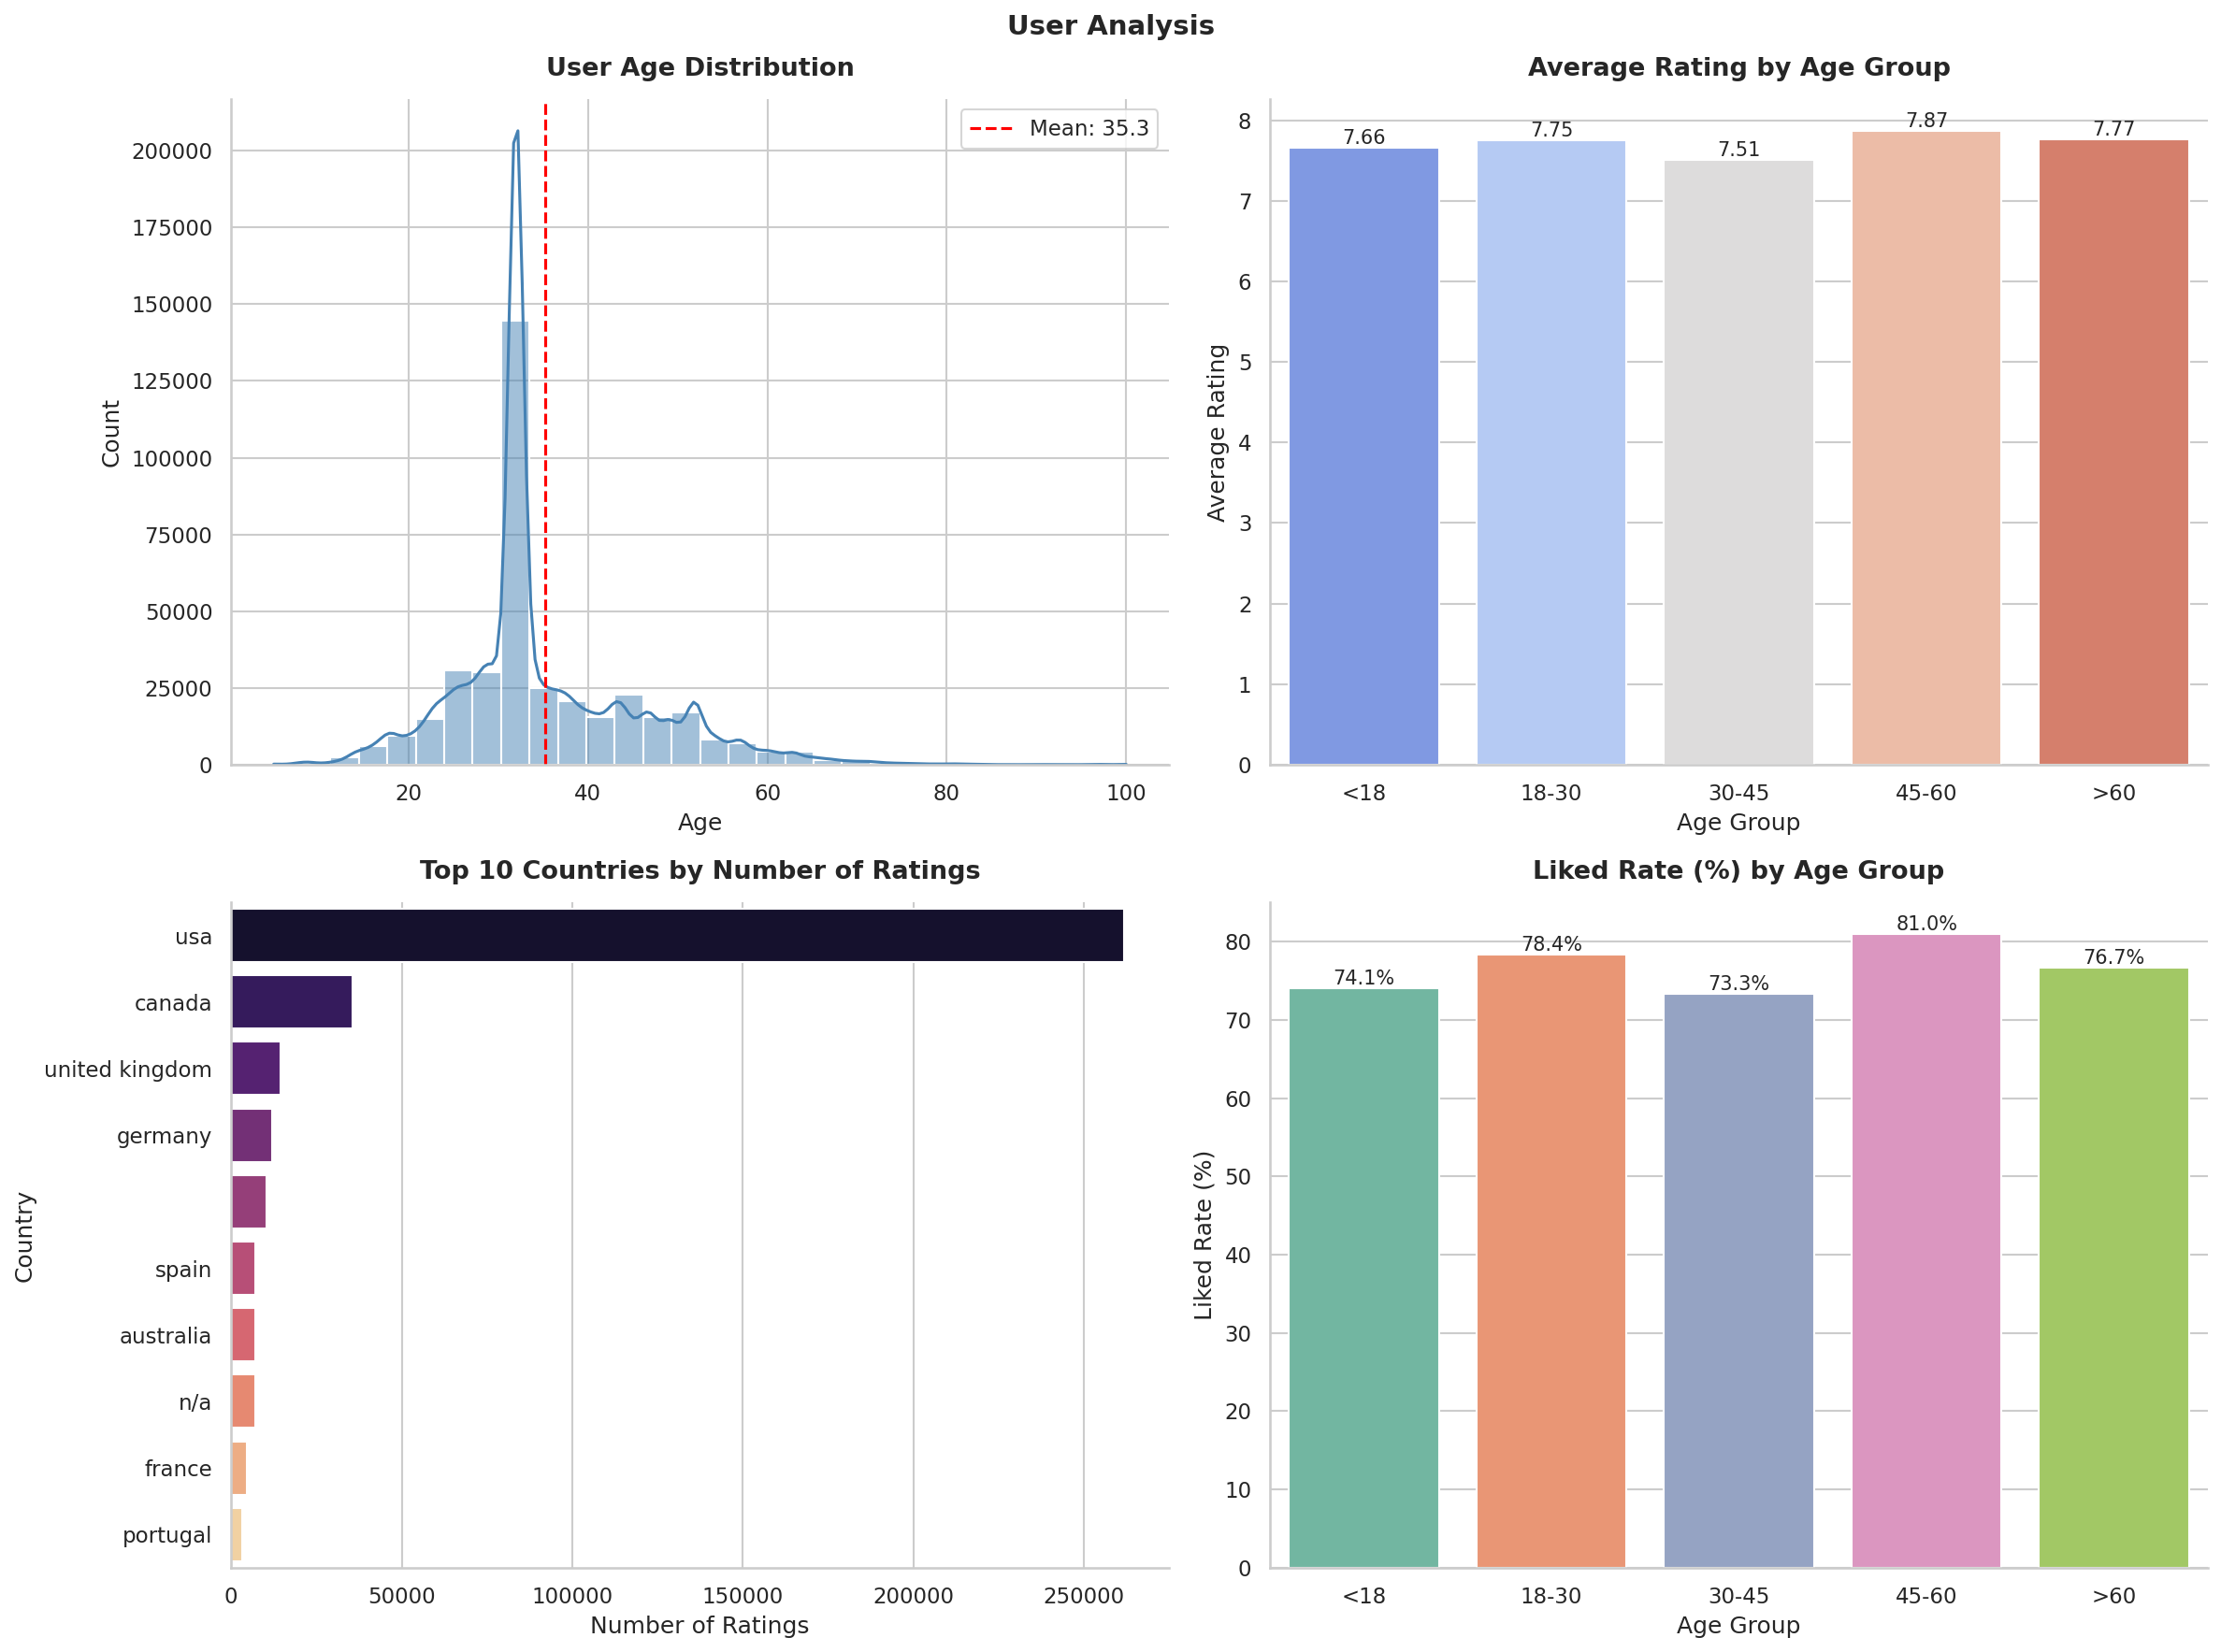

In [18]:
# Users Analysis
print("USER ANALYSIS")

# Thống kê tuổi
print(f"Average age : {df['Age'].mean():.1f}")
print(f"Median age   : {df['Age'].median():.1f}")
print(f"Minimum age   : {df['Age'].min()}")
print(f"Maximum age   : {df['Age'].max()}")

# Chia nhóm tuổi
df['Age-Group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 30, 45, 60, 100],
    labels=['<18', '18-30', '30-45', '45-60', '>60']
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Biểu đồ 1: Phân phối tuổi
sns.histplot(df['Age'], bins=30, kde=True,
             color='steelblue', ax=axes[0][0])
axes[0][0].set_title('User Age Distribution')
axes[0][0].set_xlabel('Age')
axes[0][0].set_ylabel('Count')
axes[0][0].axvline(df['Age'].mean(), color='red',
                   linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
axes[0][0].legend()

# Biểu đồ 2: Rating trung bình theo nhóm tuổi
avg_rating_age = df.groupby('Age-Group')['Book-Rating'].mean().round(2)
sns.barplot(
    x=avg_rating_age.index,
    y=avg_rating_age.values,
    palette='coolwarm',
    ax=axes[0][1]
)
axes[0][1].set_title('Average Rating by Age Group')
axes[0][1].set_xlabel('Age Group')
axes[0][1].set_ylabel('Average Rating')

# Thêm số liệu lên cột
for p in axes[0][1].patches:
    axes[0][1].annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

# Biểu đồ 3: Top 10 quốc gia
top_countries = df['Country'].value_counts().head(10)
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette='magma',
    ax=axes[1][0]
)
axes[1][0].set_title('Top 10 Countries by Number of Ratings')
axes[1][0].set_xlabel('Number of Ratings')
axes[1][0].set_ylabel('Country')

# Biểu đồ 4: Tỉ lệ Liked theo nhóm tuổi
liked_by_age = df.groupby('Age-Group')['Liked'].mean().mul(100).round(2)
sns.barplot(
    x=liked_by_age.index,
    y=liked_by_age.values,
    palette='Set2',
    ax=axes[1][1]
)
axes[1][1].set_title('Liked Rate (%) by Age Group')
axes[1][1].set_xlabel('Age Group')
axes[1][1].set_ylabel('Liked Rate (%)')

# Thêm số liệu lên cột
for p in axes[1][1].patches:
    axes[1][1].annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.suptitle('User Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_user_analysis.png', dpi=150)
plt.show()

BOOK ANALYSIS
Number of unique books  : 149,836
Number of authors       : 62,112
Number of publishers    : 11,575
Average publication year: 1996


/tmp/ipykernel_5095/906735938.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5095/906735938.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


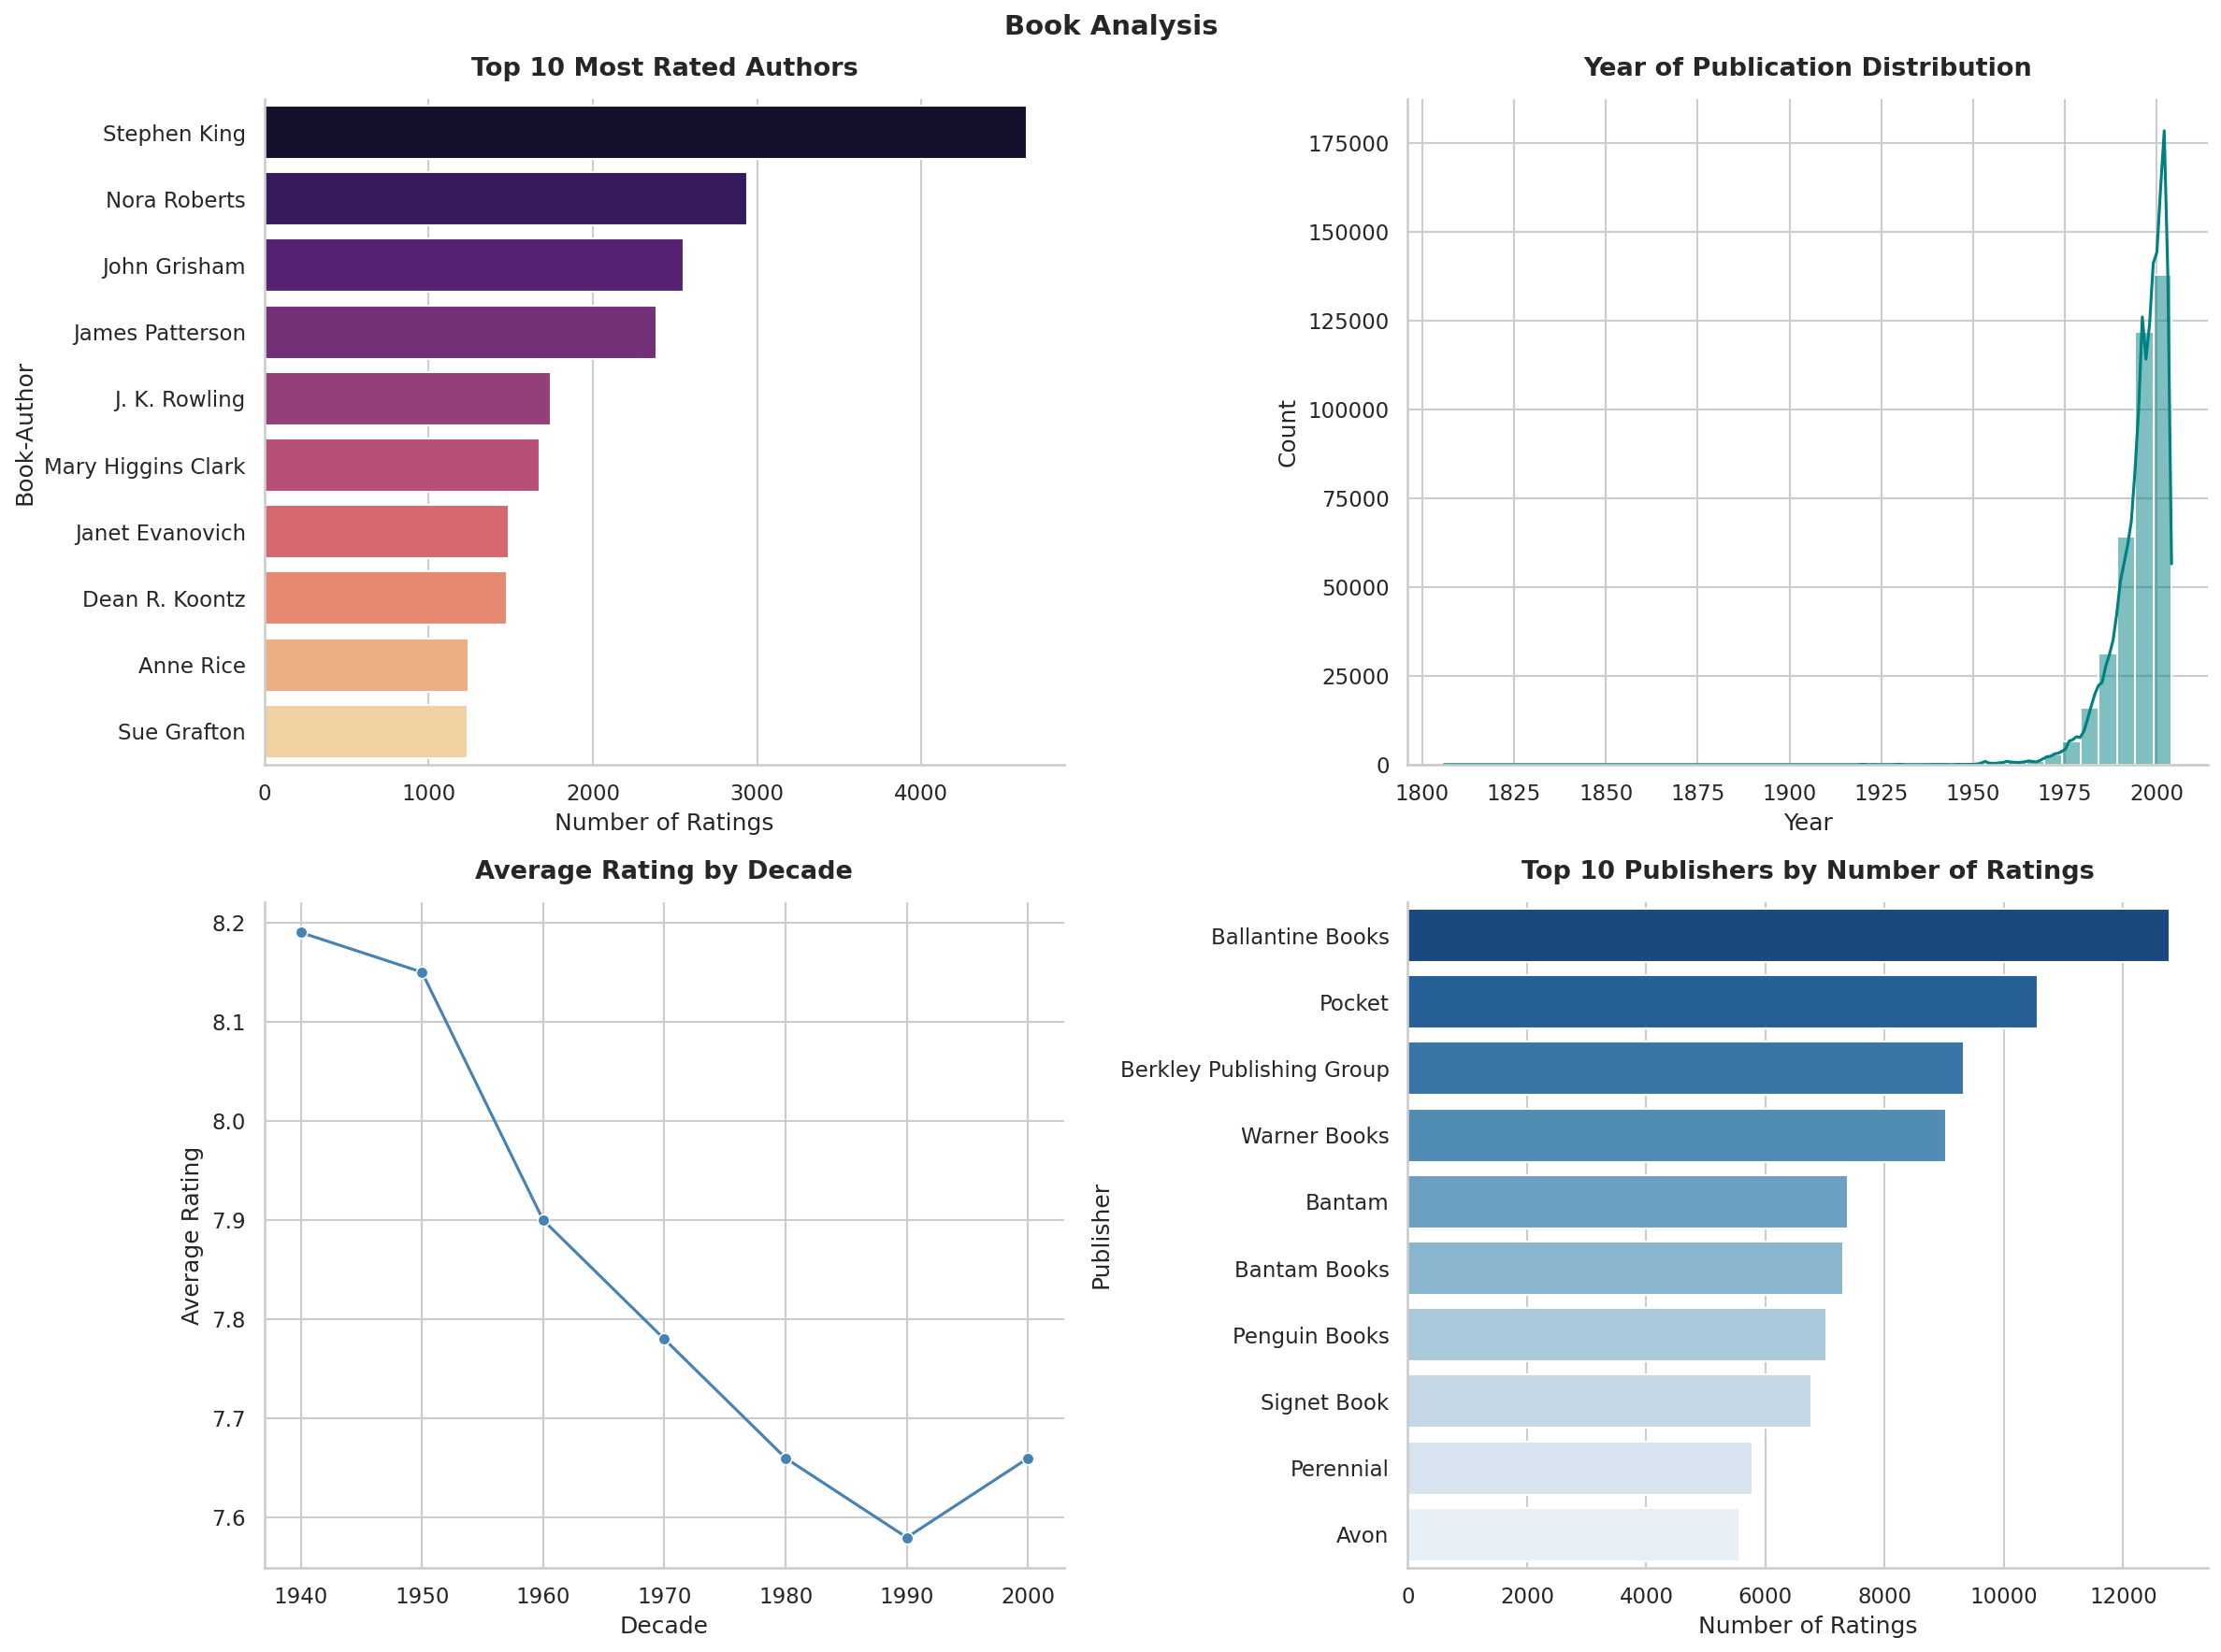

In [19]:
# Book analysis
print("BOOK ANALYSIS")

print(f"Number of unique books  : {df['ISBN'].nunique():,}")
print(f"Number of authors       : {df['Book-Author'].nunique():,}")
print(f"Number of publishers    : {df['Publisher'].nunique():,}")
print(f"Average publication year: {df['Year-Of-Publication'].mean():.0f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Biểu đồ 1: Top 10 tác giả được rating nhiều nhất
top_authors = df['Book-Author'].value_counts().head(10)
sns.barplot(
    x=top_authors.values,
    y=top_authors.index,
    palette='magma',
    ax=axes[0][0]
)
axes[0][0].set_title('Top 10 Most Rated Authors')
axes[0][0].set_xlabel('Number of Ratings')

# Biểu đồ 2: Phân phối năm xuất bản
sns.histplot(
    df['Year-Of-Publication'],
    bins=40, kde=True,
    color='teal',
    ax=axes[0][1]
)
axes[0][1].set_title('Year of Publication Distribution')
axes[0][1].set_xlabel('Year')
axes[0][1].set_ylabel('Count')

# Biểu đồ 3: Rating trung bình theo thập kỷ
df['Decade'] = (df['Year-Of-Publication'] // 10 * 10).astype(int)
avg_rating_decade = df.groupby('Decade')['Book-Rating'].mean().round(2)

# Chỉ lấy thập kỷ có đủ dữ liệu (>= 100 ratings)
decade_counts = df.groupby('Decade')['Book-Rating'].count()
valid_decades = decade_counts[decade_counts >= 100].index
avg_rating_decade = avg_rating_decade[avg_rating_decade.index.isin(valid_decades)]

sns.lineplot(
    x=avg_rating_decade.index,
    y=avg_rating_decade.values,
    marker='o', color='steelblue',
    ax=axes[1][0]
)
axes[1][0].set_title('Average Rating by Decade')
axes[1][0].set_xlabel('Decade')
axes[1][0].set_ylabel('Average Rating')

# Biểu đồ 4: Top 10 nhà xuất bản
top_publishers = df['Publisher'].value_counts().head(10)
sns.barplot(
    x=top_publishers.values,
    y=top_publishers.index,
    palette='Blues_r',
    ax=axes[1][1]
)
axes[1][1].set_title('Top 10 Publishers by Number of Ratings')
axes[1][1].set_xlabel('Number of Ratings')

plt.suptitle('Book Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_book_analysis.png', dpi=150)
plt.show()

CORRELATION MATRIX & FEATURE SELECTION


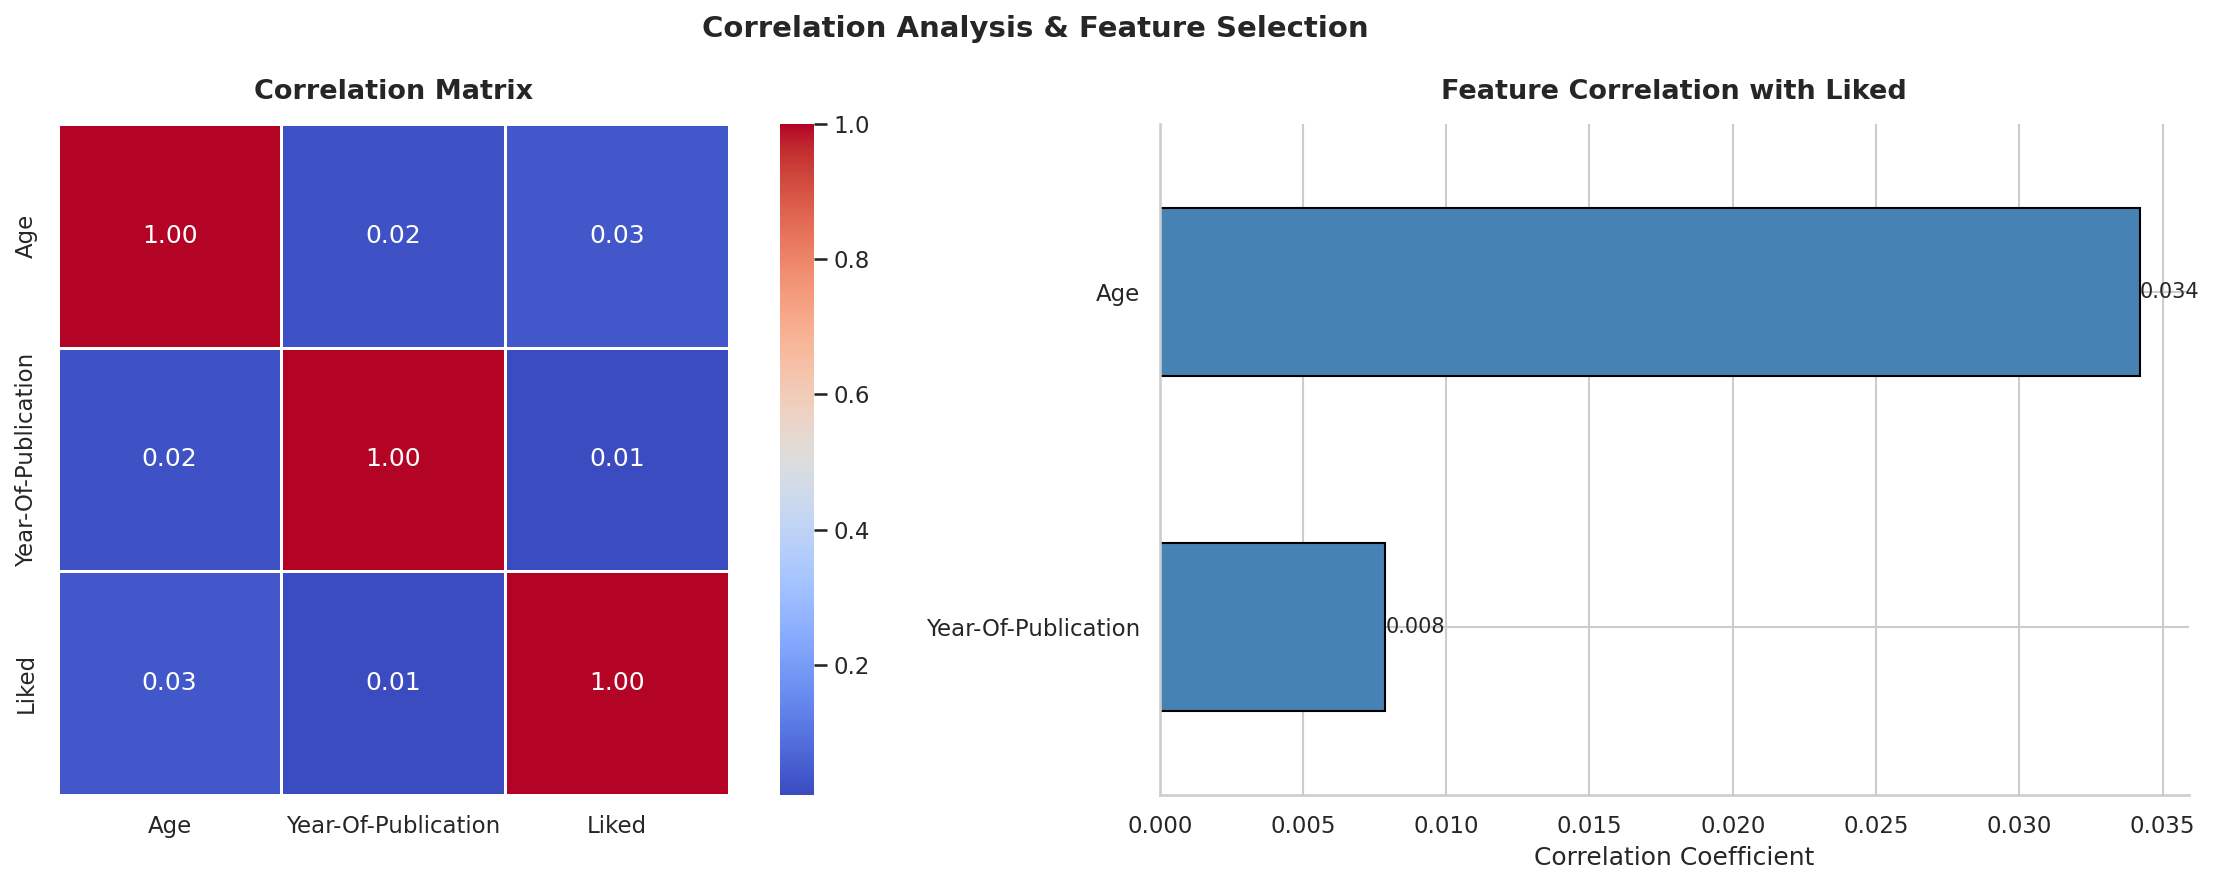


Correlation with 'Liked':
Age                    0.034214
Year-Of-Publication    0.007875
Name: Liked, dtype: float64

Feature Selection Conclusion:
   Features used for the model : ['Age', 'Year-Of-Publication']
   Target                  : 'Liked' (1 = Liked, 0 = Not Liked)


In [20]:
print("CORRELATION MATRIX & FEATURE SELECTION")

# Tính correlation matrix
numeric_cols = ['Age', 'Year-Of-Publication', 'Liked']
corr = df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Heatmap correlation
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title('Correlation Matrix')

# Biểu đồ 2: Bar chart tương quan với Liked
corr_with_target = corr['Liked'].drop('Liked').sort_values()
colors = ['salmon' if v < 0 else 'steelblue' for v in corr_with_target]
corr_with_target.plot(
    kind='barh',
    color=colors,
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title('Feature Correlation with Liked')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].axvline(x=0, color='black', linewidth=0.8)

# Thêm số liệu lên cột
for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_width():.3f}',
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha='left', va='center', fontsize=10
    )

plt.suptitle('Correlation Analysis & Feature Selection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_correlation_matrix.png', dpi=150)
plt.show()

# In kết luận feature selection
print("\nCorrelation with 'Liked':")
print(corr['Liked'].drop('Liked').sort_values(ascending=False))

print("\nFeature Selection Conclusion:")
print("   Features used for the model : ['Age', 'Year-Of-Publication']")
print("   Target                  : 'Liked' (1 = Liked, 0 = Not Liked)")

RATING BEHAVIOR ANALYSIS


/tmp/ipykernel_5095/145063020.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5095/145063020.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5095/145063020.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


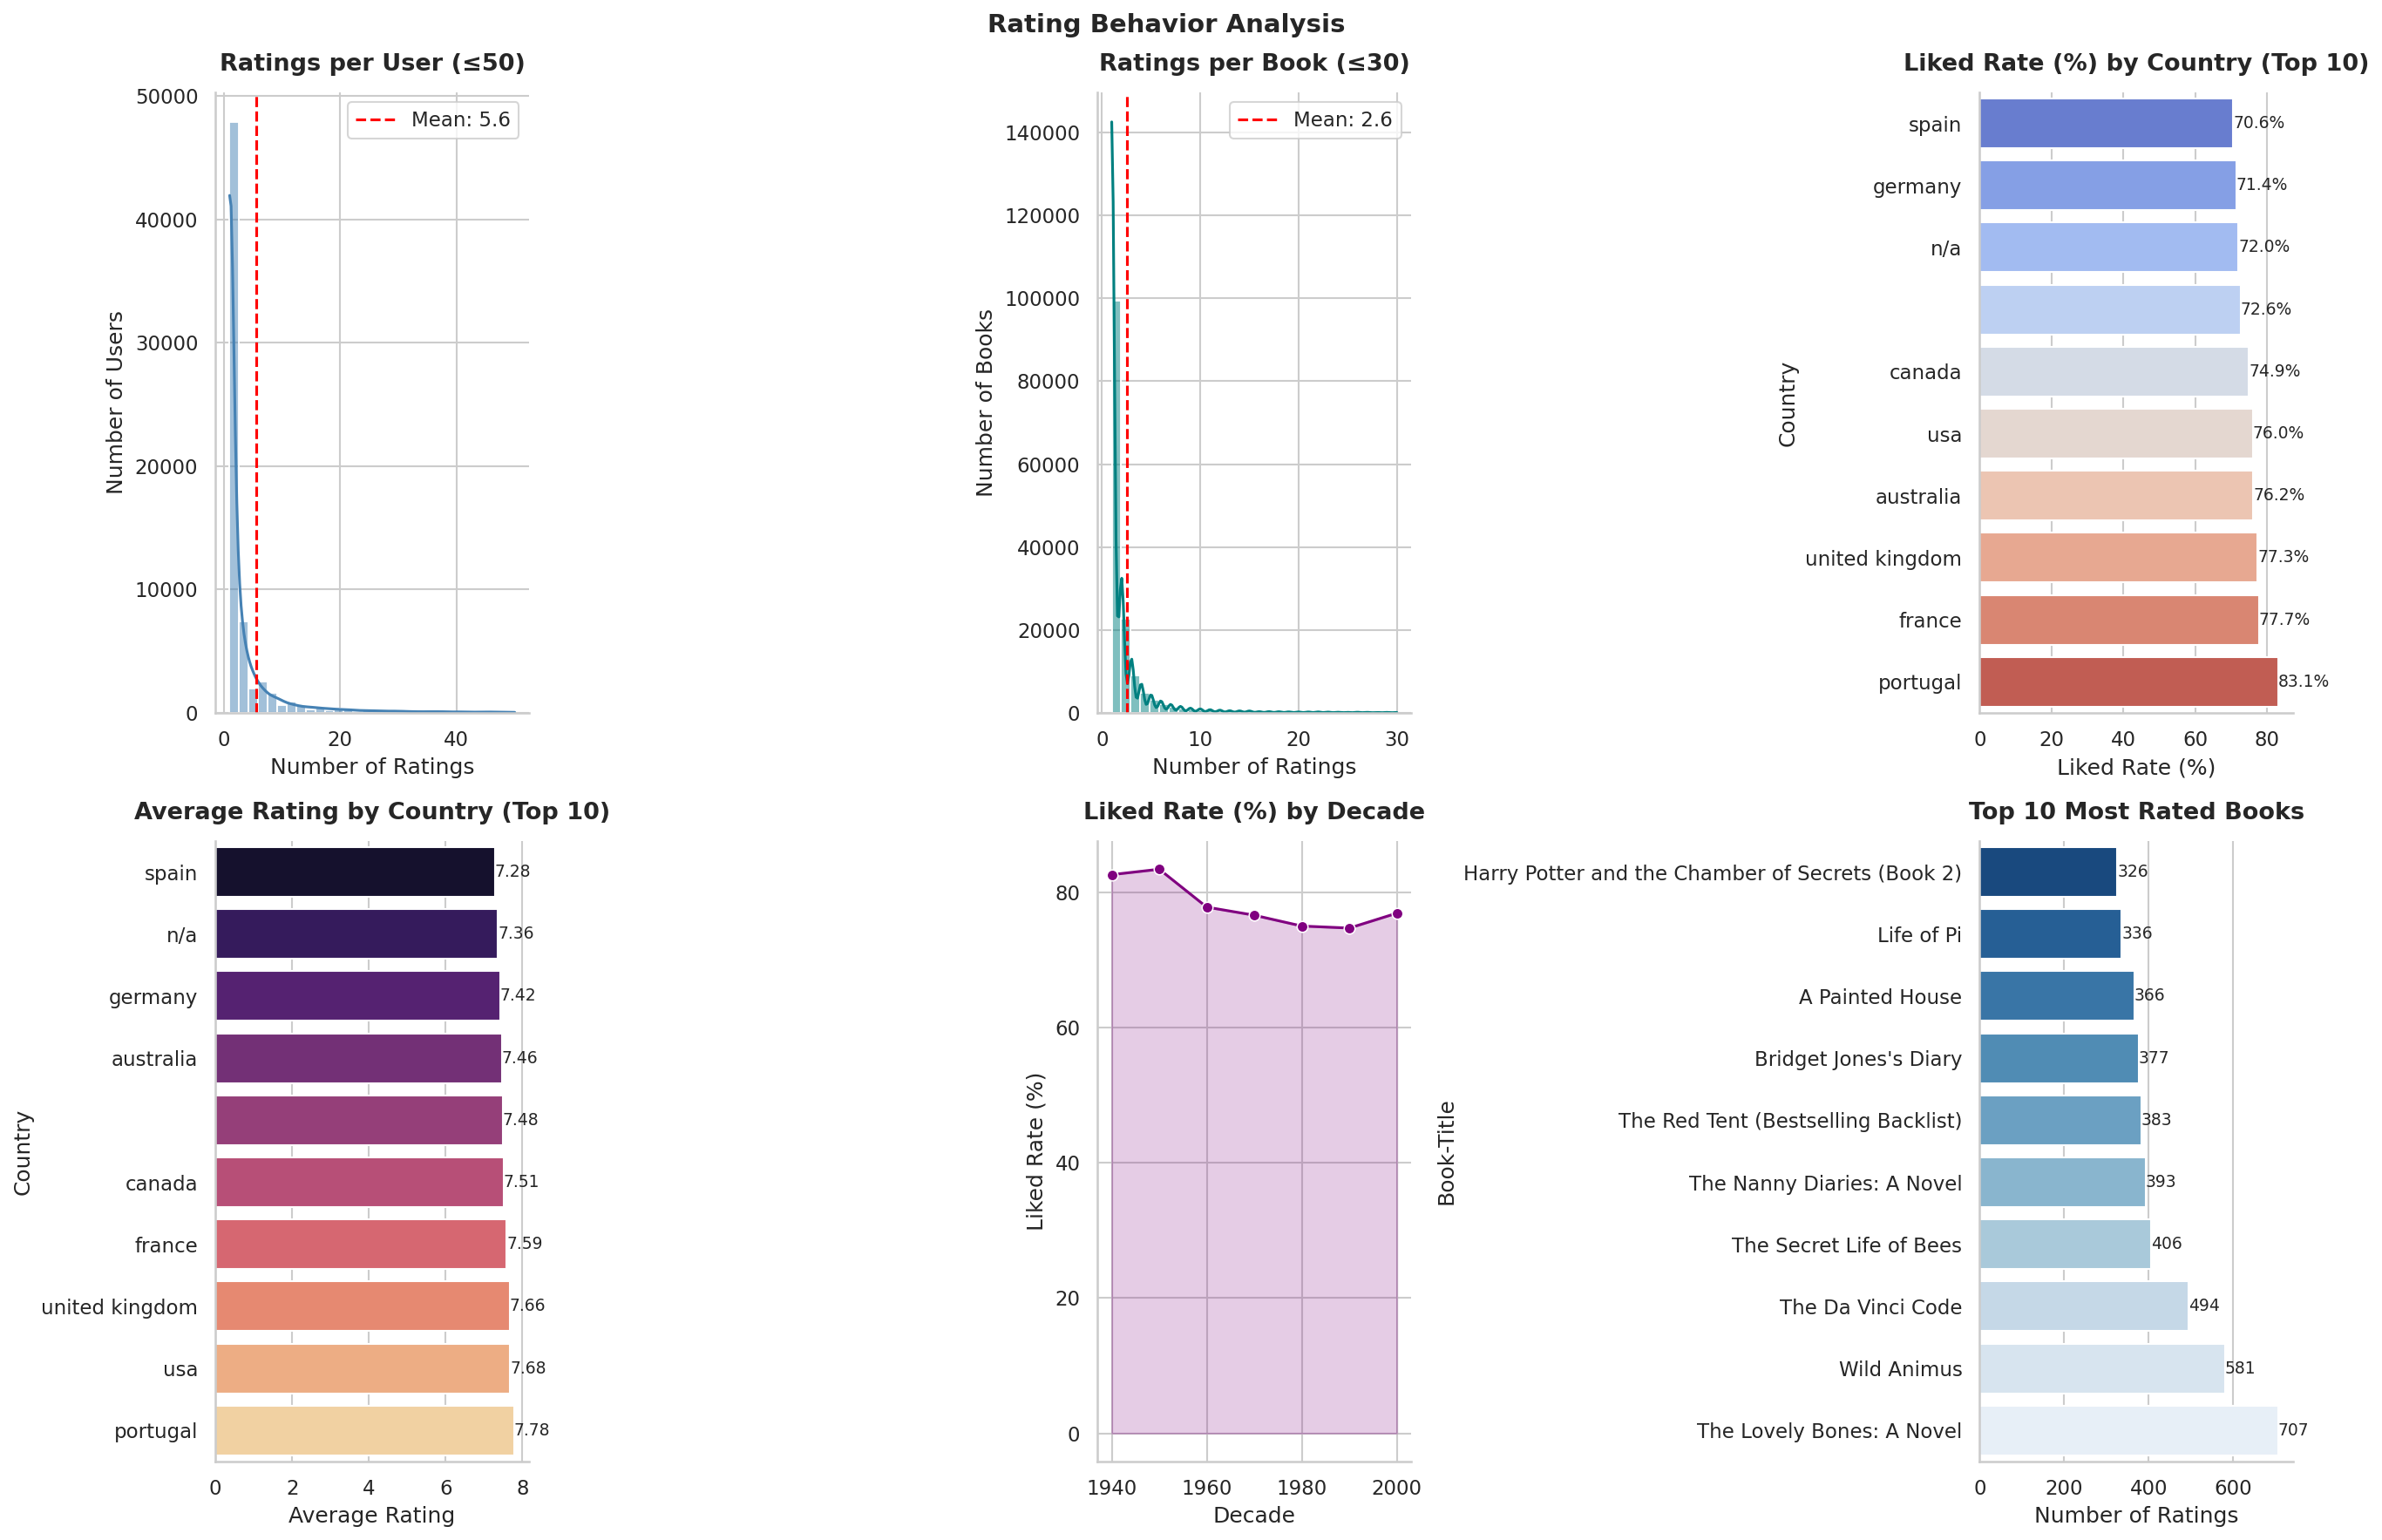

In [21]:
#  RATING BEHAVIOR ANALYSIS
print("RATING BEHAVIOR ANALYSIS")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Biểu đồ 1: Số ratings per user (distribution)
ratings_per_user = df.groupby('User-ID')['Book-Rating'].count()
sns.histplot(
    ratings_per_user[ratings_per_user <= 50],  # filter outliers
    bins=30, kde=True, color='steelblue', ax=axes[0][0]
)
axes[0][0].set_title('Ratings per User (≤50)')
axes[0][0].set_xlabel('Number of Ratings')
axes[0][0].set_ylabel('Number of Users')
axes[0][0].axvline(ratings_per_user.mean(), color='red',
                   linestyle='--', label=f'Mean: {ratings_per_user.mean():.1f}')
axes[0][0].legend()

# Biểu đồ 2: Số ratings per book (distribution)
ratings_per_book = df.groupby('ISBN')['Book-Rating'].count()
sns.histplot(
    ratings_per_book[ratings_per_book <= 30],
    bins=30, kde=True, color='teal', ax=axes[0][1]
)
axes[0][1].set_title('Ratings per Book (≤30)')
axes[0][1].set_xlabel('Number of Ratings')
axes[0][1].set_ylabel('Number of Books')
axes[0][1].axvline(ratings_per_book.mean(), color='red',
                   linestyle='--', label=f'Mean: {ratings_per_book.mean():.1f}')
axes[0][1].legend()

# Biểu đồ 3: Liked rate theo Country (top 10)
top_countries = df['Country'].value_counts().head(10).index
liked_by_country = (
    df[df['Country'].isin(top_countries)]
    .groupby('Country')['Liked'].mean()
    .mul(100).round(1)
    .sort_values(ascending=True)
)
sns.barplot(
    x=liked_by_country.values,
    y=liked_by_country.index,
    palette='coolwarm', ax=axes[0][2]
)
axes[0][2].set_title('Liked Rate (%) by Country (Top 10)')
axes[0][2].set_xlabel('Liked Rate (%)')
for p in axes[0][2].patches:
    axes[0][2].annotate(
        f'{p.get_width():.1f}%',
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha='left', va='center', fontsize=9
    )

# Biểu đồ 4: Average rating theo Country (top 10)
avg_rating_country = (
    df[df['Country'].isin(top_countries)]
    .groupby('Country')['Book-Rating'].mean()
    .round(2).sort_values(ascending=True)
)
sns.barplot(
    x=avg_rating_country.values,
    y=avg_rating_country.index,
    palette='magma', ax=axes[1][0]
)
axes[1][0].set_title('Average Rating by Country (Top 10)')
axes[1][0].set_xlabel('Average Rating')
for p in axes[1][0].patches:
    axes[1][0].annotate(
        f'{p.get_width():.2f}',
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha='left', va='center', fontsize=9
    )

# Biểu đồ 5: Liked rate theo Decade
liked_by_decade = (
    df.groupby('Decade')['Liked'].mean()
    .mul(100).round(1)
)
decade_counts = df.groupby('Decade')['Liked'].count()
valid_decades = decade_counts[decade_counts >= 100].index
liked_by_decade = liked_by_decade[liked_by_decade.index.isin(valid_decades)]

sns.lineplot(
    x=liked_by_decade.index,
    y=liked_by_decade.values,
    marker='o', color='purple', ax=axes[1][1]
)
axes[1][1].set_title('Liked Rate (%) by Decade')
axes[1][1].set_xlabel('Decade')
axes[1][1].set_ylabel('Liked Rate (%)')
axes[1][1].fill_between(liked_by_decade.index,
                         liked_by_decade.values, alpha=0.2, color='purple')

# Biểu đồ 6: Top 10 sách được rating nhiều nhất
top_books = (
    df.groupby('Book-Title')['Book-Rating']
    .count().sort_values(ascending=True).tail(10)
)
sns.barplot(
    x=top_books.values,
    y=top_books.index,
    palette='Blues_r', ax=axes[1][2]
)
axes[1][2].set_title('Top 10 Most Rated Books')
axes[1][2].set_xlabel('Number of Ratings')
for p in axes[1][2].patches:
    axes[1][2].annotate(
        f'{int(p.get_width()):,}',
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha='left', va='center', fontsize=9
    )

plt.suptitle('Rating Behavior Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_rating_behavior.png', dpi=150)
plt.show()

In [22]:
import shutil
# Lưu ảnh
images = [
    '01_target_distribution.png',
    '02_rating_analysis.png',
    '03_user_analysis.png',
    '04_book_analysis.png',
    '05_correlation_matrix.png',
    '06_rating_behavior.png'
]
for img in images:
    shutil.copy(f'/content/{img}', DATA_PATH + img)

# Lưu merged dataframe
df.to_csv(DATA_PATH + 'data_clean_merged.csv', index=False)

print("All files saved to Drive!")

All files saved to Drive!


In [23]:
print(df.columns.tolist())
print(df.shape)
df.describe()

['User-ID', 'ISBN', 'Book-Rating', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Location', 'Age', 'City', 'State', 'Country', 'Liked', 'Age-Group', 'Decade']
(383842, 15)


,User-ID,Book-Rating,Year-Of-Publication,Age,Liked,Decade
count,383842.000000,383842.000000,383842.000000,383842.000000,383842.000000,383842.000000
mean,136031.461260,7.626701,1995.707869,35.252948,0.756064,1991.572835
std,80482.299401,1.841339,7.242996,10.511052,0.429455,8.193417
min,8.000000,1.000000,1806.000000,5.000000,0.000000,1800.000000
25%,67591.000000,7.000000,1993.000000,31.000000,1.000000,1990.000000
50%,133789.000000,8.000000,1997.000000,32.000000,1.000000,1990.000000
75%,206219.000000,9.000000,2001.000000,40.000000,1.000000,2000.000000
max,278854.000000,10.000000,2004.000000,100.000000,1.000000,2000.000000


Feature Engineering

In [24]:
!pip install imbalanced-learn xgboost -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

!pip install -q imbalanced-learn
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import LogisticRegression
from sklearn.metrics      import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

from sklearn.tree        import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

!pip install -q xgboost
from xgboost import XGBClassifier

In [25]:
df = pd.read_csv(DATA_PATH + 'data_clean_merged.csv')

In [26]:
# ── Xác định X, y ─────────────────────────────────────────────
BASE_COLS = [
    'ISBN', 'User-ID', 'Age', 'Year-Of-Publication',
    'Book-Author', 'Publisher', 'Liked'
]

df_model = df[BASE_COLS].copy()

X_raw = df_model.drop(columns=['Liked'])
y = df_model['Liked']

# ── Train/Test Split ──────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ── Dùng rating gốc để tạo aggregated features ───────────────
train_with_rating = X_train_raw.join(
    df[['Book-Rating']].loc[X_train_raw.index]
)

# Global mean rating
global_mean = train_with_rating['Book-Rating'].mean()

# Book statistics
book_stats = train_with_rating.groupby('ISBN')['Book-Rating'].agg(
    book_avg_rating='mean',
    book_rating_count='count'
).reset_index()

# User statistics
user_stats = train_with_rating.groupby('User-ID')['Book-Rating'].agg(
    user_avg_rating='mean',
    user_rating_count='count'
).reset_index()

# ── Function thêm aggregated features ─────────────────────────
def add_agg_features(df_split):

    df_split = df_split.merge(
        book_stats,
        on='ISBN',
        how='left'
    )

    df_split = df_split.merge(
        user_stats,
        on='User-ID',
        how='left'
    )

    # Fill missing values
    df_split['book_avg_rating'] = (
        df_split['book_avg_rating'].fillna(global_mean)
    )

    df_split['book_rating_count'] = (
        df_split['book_rating_count'].fillna(0)
    )

    df_split['user_avg_rating'] = (
        df_split['user_avg_rating'].fillna(global_mean)
    )

    df_split['user_rating_count'] = (
        df_split['user_rating_count'].fillna(0)
    )

    return df_split

# ── Apply features ────────────────────────────────────────────
X_train_raw = add_agg_features(X_train_raw)
X_test_raw = add_agg_features(X_test_raw)

print("✓ Aggregated features added — no leakage")
print(f"Train shape: {X_train_raw.shape}")
print(f"Test shape : {X_test_raw.shape}")

✓ Aggregated features added — no leakage
Train shape: (307073, 10)
Test shape : (76769, 10)


In [27]:
# Encode categorical: Book-Author và Publisher

author_freq    = df['Book-Author'].value_counts() / len(df)
publisher_freq = df['Publisher'].value_counts()   / len(df)

df['author_freq']    = df['Book-Author'].map(author_freq).fillna(0)
df['publisher_freq'] = df['Publisher'].map(publisher_freq).fillna(0)

print("Frequency encoding done.")
print(df[['Book-Author','author_freq','Publisher','publisher_freq']].head(3))

Frequency encoding done.
     Book-Author  author_freq                   Publisher  publisher_freq
0     Judith Rae     0.000003                      Heinle        0.000034
1  Philip Prowse     0.000005  Cambridge University Press        0.000516
2    Sue Leather     0.000003  Cambridge University Press        0.000516


In [28]:
# ── Final Feature Selection ───────────────────────────────────

FEATURE_COLS = [
    'Age',
    'Year-Of-Publication',
    'book_avg_rating',
    'book_rating_count',
    'user_avg_rating',
    'user_rating_count'
]

# Select train/test features
X_train = X_train_raw[FEATURE_COLS].copy()
X_test  = X_test_raw[FEATURE_COLS].copy()

# Targets
y_train = y_train.copy()
y_test  = y_test.copy()

# ── Check dataset ─────────────────────────────────────────────
print("=" * 50)
print("FEATURE SET")
print("=" * 50)

print(f"\nFeatures:")
for col in FEATURE_COLS:
    print(f" - {col}")

print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")

print("\nClass distribution:")
print(y_train.value_counts())

print("\nMissing values in X_train:")
print(X_train.isnull().sum())

# ── Scale Features ────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✓ Features scaled successfully")
print(f"Scaled train shape: {X_train_scaled.shape}")

FEATURE SET

Features:
 - Age
 - Year-Of-Publication
 - book_avg_rating
 - book_rating_count
 - user_avg_rating
 - user_rating_count

X_train shape : (307073, 6)
X_test shape  : (76769, 6)

Class distribution:
Liked
1    232167
0     74906
Name: count, dtype: int64

Missing values in X_train:
Age                    0
Year-Of-Publication    0
book_avg_rating        0
book_rating_count      0
user_avg_rating        0
user_rating_count      0
dtype: int64

✓ Features scaled successfully
Scaled train shape: (307073, 6)


Train/Test Split & Handle Class Imbalance

In [29]:
# ── TRAIN / TEST INFORMATION ─────────────────────────────────

print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)

total_samples = X_train.shape[0] + X_test.shape[0]

print(f"\nTrain : {X_train.shape[0]:,} "
      f"({X_train.shape[0] / total_samples * 100:.1f}%)")

print(f"Test  : {X_test.shape[0]:,} "
      f"({X_test.shape[0] / total_samples * 100:.1f}%)")

print("\nClass distribution – Train:")
print(y_train.value_counts())

print("\nClass distribution – Test:")
print(y_test.value_counts())

print("\nMissing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())

TRAIN / TEST SPLIT

Train : 307,073 (80.0%)
Test  : 76,769 (20.0%)

Class distribution – Train:
Liked
1    232167
0     74906
Name: count, dtype: int64

Class distribution – Test:
Liked
1    58042
0    18727
Name: count, dtype: int64

Missing values in X_train:
Age                    0
Year-Of-Publication    0
book_avg_rating        0
book_rating_count      0
user_avg_rating        0
user_rating_count      0
dtype: int64

Missing values in X_test:
Age                    0
Year-Of-Publication    0
book_avg_rating        0
book_rating_count      0
user_avg_rating        0
user_rating_count      0
dtype: int64


In [30]:
# Scale features (for Logistic Regression & SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("StandardScaler applied.")
print(f"Mean ≈ {X_train_scaled.mean():.4f}  (expected ~0)")
print(f"Std  ≈ {X_train_scaled.std():.4f}   (expected ~1)")

StandardScaler applied.
Mean ≈ -0.0000  (expected ~0)
Std  ≈ 1.0000   (expected ~1)


In [31]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/team_data/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Train size before SMOTE : 307,073
Train size after SMOTE   : 464,334
Class distribution sau SMOTE:
Liked
1    232167
0    232167
Name: count, dtype: int64


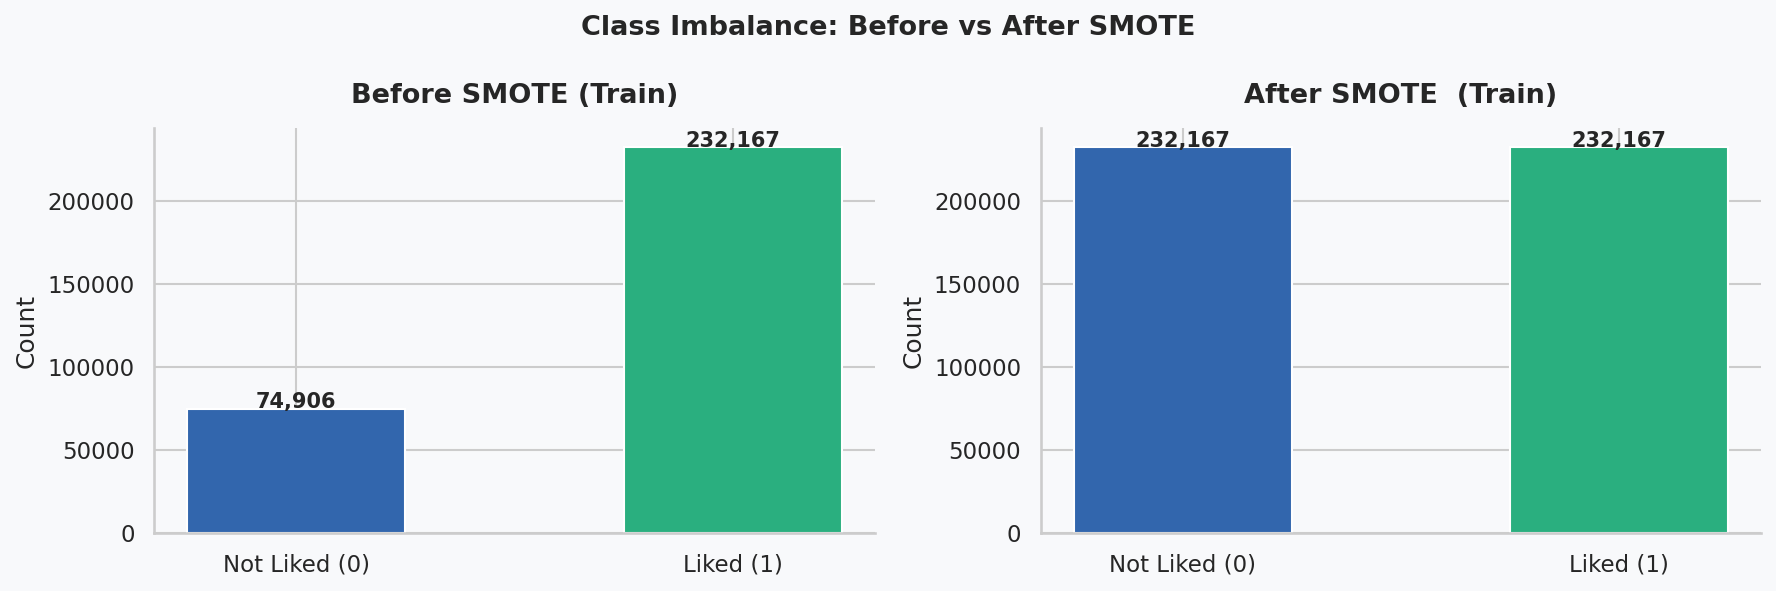

'/content/drive/MyDrive/team_data/06_smote_comparison.png'

In [32]:
# Handle class imbalance by SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"Train size before SMOTE : {len(y_train):,}")
print(f"Train size after SMOTE   : {len(y_train_sm):,}")
print(f"Class distribution sau SMOTE:\n{pd.Series(y_train_sm).value_counts()}")

# Visualize Before vs After SMOTE
BG = '#F8F9FB'
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=BG)

for ax, (y_data, title) in zip(axes, [
    (y_train,    'Before SMOTE (Train)'),
    (y_train_sm, 'After SMOTE  (Train)'),
]):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar(['Not Liked (0)', 'Liked (1)'], counts.values,
                  color=['#3266AD','#2AAF7F'], edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_facecolor(BG)
    ax.spines[['top','right']].set_visible(False)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 200,
                f'{v:,}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Class Imbalance: Before vs After SMOTE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_smote_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

import shutil
shutil.copy('/content/06_smote_comparison.png', DATA_PATH + '06_smote_comparison.png')

Baseline Model – Logistic Regression

In [33]:
# BASELINE MODEL: Logistic Regression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

y_pred_lr  = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

metrics_lr = {
    'Accuracy' : accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_lr),
    'F1-Score' : f1_score(y_test, y_pred_lr),
    'AUC-ROC'  : roc_auc_score(y_test, y_proba_lr),
}

print("=" * 45)
print("  BASELINE: Logistic Regression")
print("=" * 45)
for k, v in metrics_lr.items():
    print(f"  {k:<12}: {v:.4f}")
print()
print(classification_report(y_test, y_pred_lr,
                             target_names=['Not Liked', 'Liked']))

  BASELINE: Logistic Regression
  Accuracy    : 0.7294
  Precision   : 0.8212
  Recall      : 0.8207
  F1-Score    : 0.8210
  AUC-ROC     : 0.7014

              precision    recall  f1-score   support

   Not Liked       0.45      0.45      0.45     18727
       Liked       0.82      0.82      0.82     58042

    accuracy                           0.73     76769
   macro avg       0.63      0.63      0.63     76769
weighted avg       0.73      0.73      0.73     76769



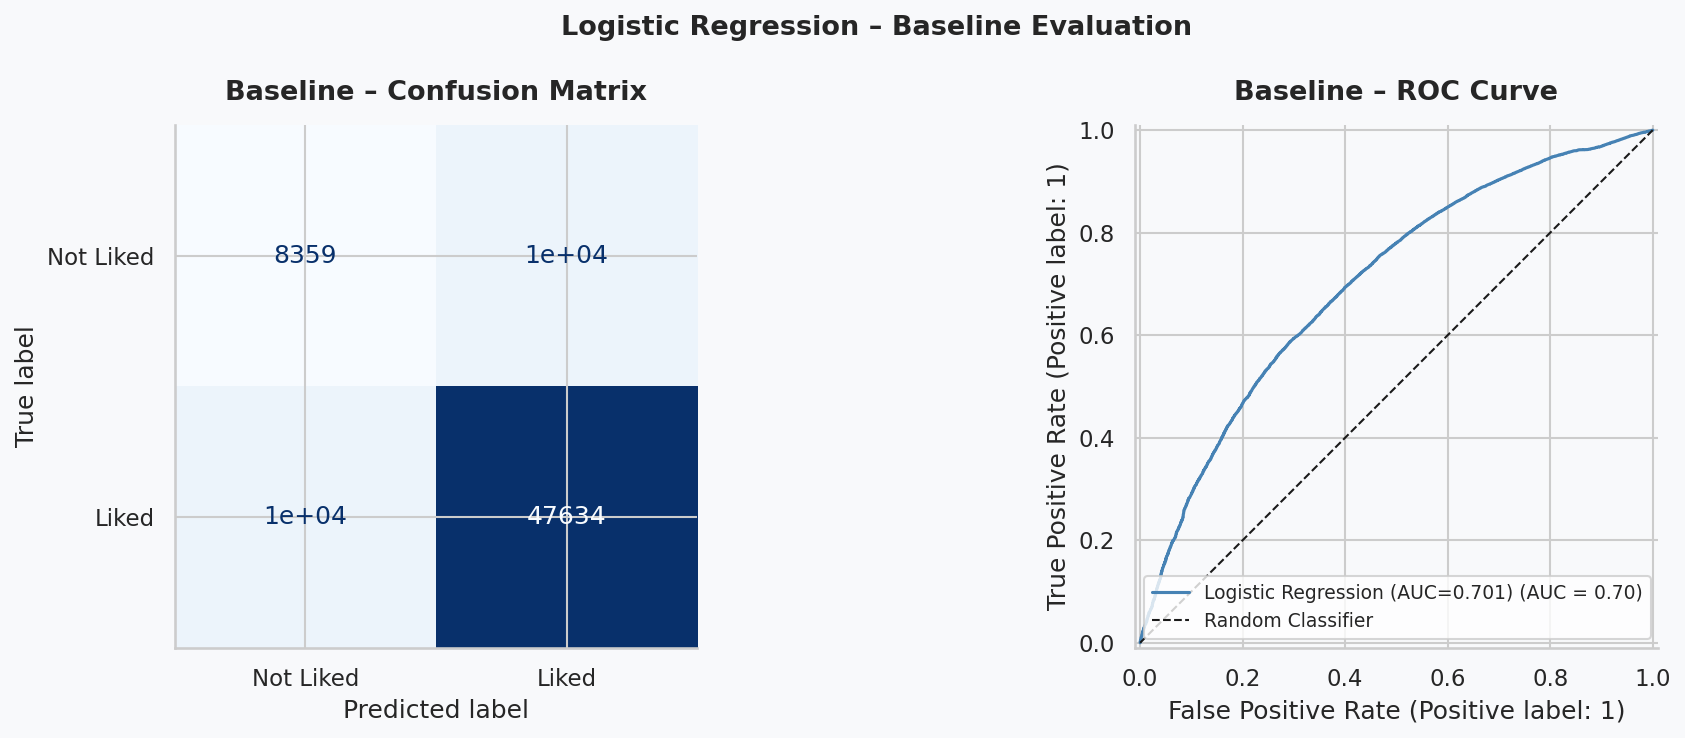

'/content/drive/MyDrive/team_data/07_baseline_logistic.png'

In [34]:
# ── Visualize Baseline: Confusion Matrix + ROC Curve ─────────
BG = '#F8F9FB'
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=['Not Liked', 'Liked']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Baseline – Confusion Matrix', fontweight='bold')
axes[0].set_facecolor(BG)

RocCurveDisplay.from_predictions(
    y_test, y_proba_lr,
    name=f"Logistic Regression (AUC={metrics_lr['AUC-ROC']:.3f})",
    ax=axes[1], color='steelblue'
)
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
axes[1].set_title('Baseline – ROC Curve', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_facecolor(BG)

plt.suptitle('Logistic Regression – Baseline Evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_baseline_logistic.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

shutil.copy('/content/07_baseline_logistic.png', DATA_PATH + '07_baseline_logistic.png')

Decision Tree – GridSearchCV

In [35]:
# Tree-based models dùng X_train_sm (SMOTE), no scaled
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

dt_param_grid = {
    'max_depth'        : [5, 10, 20],       # bỏ None — None rất chậm trên SMOTE data
    'min_samples_split': [10, 20],           # bỏ 2 — dễ overfit, không cần thiết
    'min_samples_leaf' : [1, 5, 10],
    'criterion'        : ['gini', 'entropy'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train_sm, y_train_sm)

print(f"Best params : {dt_grid.best_params_}")
print(f"Best CV F1  : {dt_grid.best_score_:.4f}")

# ── Evaluation
best_dt = dt_grid.best_estimator_

y_pred_dt  = best_dt.predict(X_test)
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params : {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 20}
Best CV F1  : 0.8870


In [36]:
# Evaluate Decision Tree on test
best_dt    = dt_grid.best_estimator_
y_pred_dt  = best_dt.predict(X_test)
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]

metrics_dt = {
    'Accuracy' : accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_dt),
    'F1-Score' : f1_score(y_test, y_pred_dt),
    'AUC-ROC'  : roc_auc_score(y_test, y_proba_dt),
}

print("=" * 45)
print("  Decision Tree (tuned)")
print("=" * 45)
for k, v in metrics_dt.items():
    print(f"  {k:<12}: {v:.4f}")
print()
print(classification_report(y_test, y_pred_dt,
                             target_names=['Not Liked', 'Liked']))

  Decision Tree (tuned)
  Accuracy    : 0.5801
  Precision   : 0.8249
  Recall      : 0.5644
  F1-Score    : 0.6702
  AUC-ROC     : 0.5963

              precision    recall  f1-score   support

   Not Liked       0.32      0.63      0.42     18727
       Liked       0.82      0.56      0.67     58042

    accuracy                           0.58     76769
   macro avg       0.57      0.60      0.55     76769
weighted avg       0.70      0.58      0.61     76769



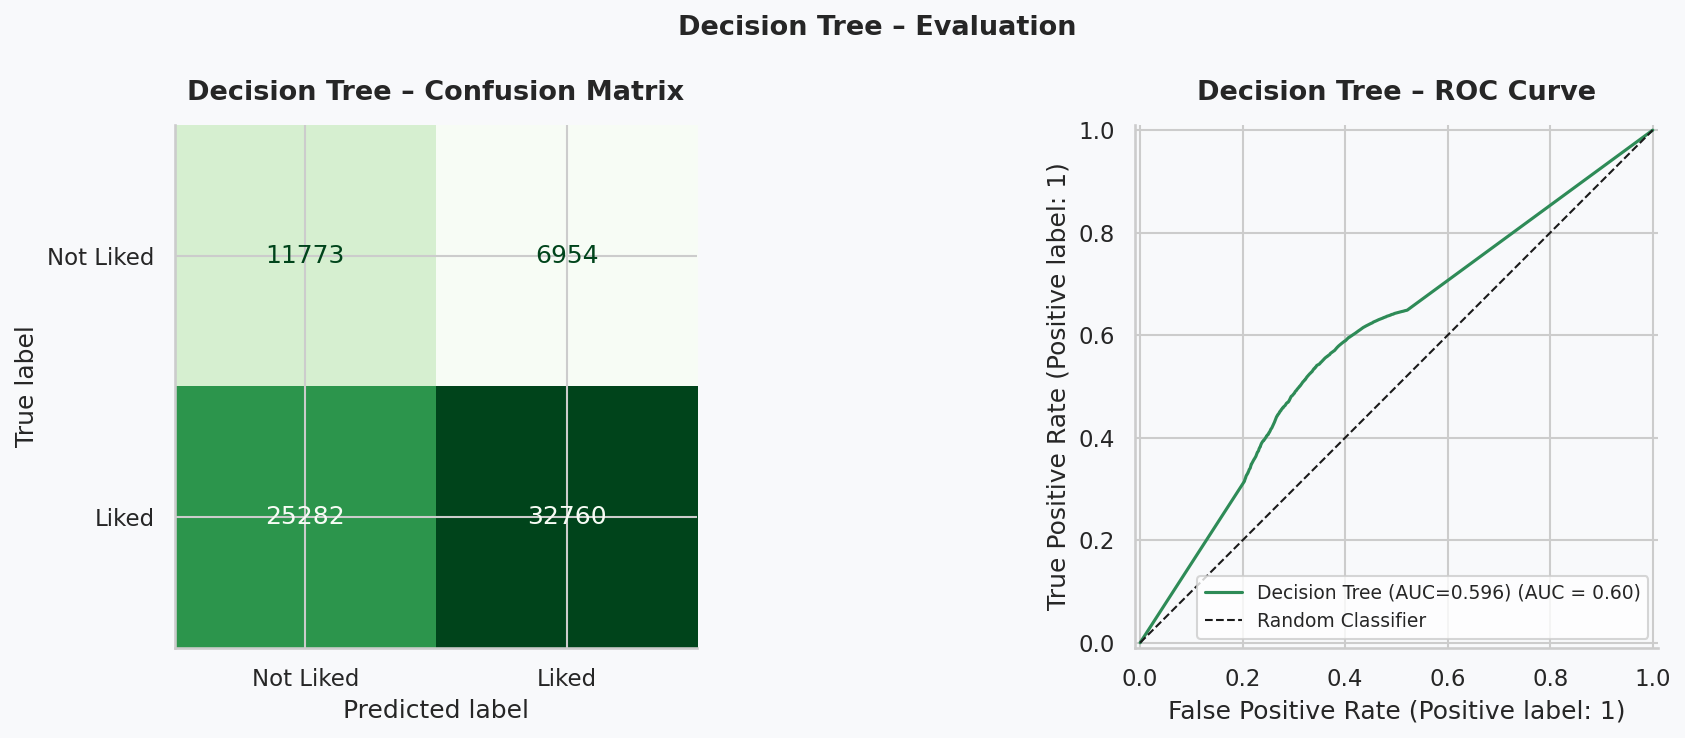

'/content/drive/MyDrive/team_data/08_decision_tree.png'

In [37]:
# Visualize Decision Tree results
BG = '#F8F9FB'
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_dt),
    display_labels=['Not Liked', 'Liked']
).plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Decision Tree – Confusion Matrix', fontweight='bold')
axes[0].set_facecolor(BG)

RocCurveDisplay.from_predictions(
    y_test, y_proba_dt,
    name=f"Decision Tree (AUC={metrics_dt['AUC-ROC']:.3f})",
    ax=axes[1], color='seagreen'
)
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
axes[1].set_title('Decision Tree – ROC Curve', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_facecolor(BG)

plt.suptitle('Decision Tree – Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('08_decision_tree.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

shutil.copy('/content/08_decision_tree.png', DATA_PATH + '08_decision_tree.png')

Support Vector Machine (SVM)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params : {'estimator__C': 0.1}
Best CV F1  : 0.8396
  SVM – LinearSVC (tuned)
  Accuracy    : 0.6281
  Precision   : 0.8622
  Recall      : 0.6048
  F1-Score    : 0.7109
  AUC-ROC     : 0.7076

              precision    recall  f1-score   support

   Not Liked       0.36      0.70      0.48     18727
       Liked       0.86      0.60      0.71     58042

    accuracy                           0.63     76769
   macro avg       0.61      0.65      0.59     76769
weighted avg       0.74      0.63      0.65     76769



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: U

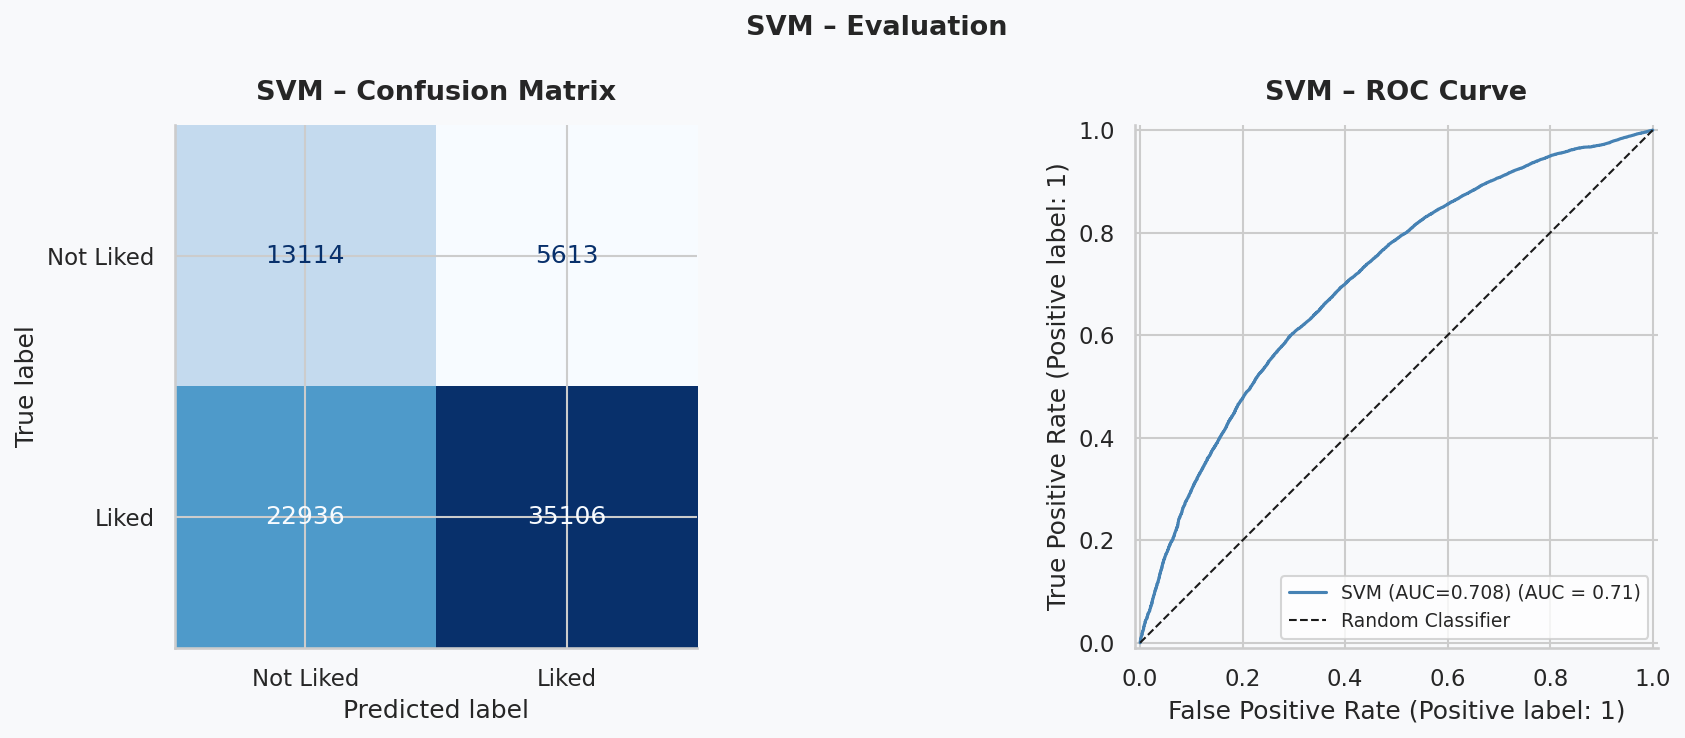

'/content/drive/MyDrive/team_data/08b_svm.png'

In [38]:
# ══════════════════════════════════════════════════
#  SVM — LinearSVC (phù hợp dataset lớn)
# ══════════════════════════════════════════════════
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_param_grid = {
    'estimator__C': [0.01, 0.1, 1.0, 10.0],
}

# CalibratedClassifierCV để có predict_proba
svm_base = CalibratedClassifierCV(
    LinearSVC(max_iter=2000, random_state=42),
    cv=3
)

svm_grid = GridSearchCV(
    svm_base,
    svm_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
svm_grid.fit(X_train_sm, y_train_sm)   # dùng scaled + SMOTE

print(f"Best params : {svm_grid.best_params_}")
print(f"Best CV F1  : {svm_grid.best_score_:.4f}")

# Evaluate SVM
best_svm    = svm_grid.best_estimator_
y_pred_svm  = best_svm.predict(X_test_scaled)
y_proba_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

metrics_svm = {
    'Accuracy' : accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_svm),
    'F1-Score' : f1_score(y_test, y_pred_svm),
    'AUC-ROC'  : roc_auc_score(y_test, y_proba_svm),
}

print("=" * 45)
print("  SVM – LinearSVC (tuned)")
print("=" * 45)
for k, v in metrics_svm.items():
    print(f"  {k:<12}: {v:.4f}")
print()
print(classification_report(y_test, y_pred_svm,
                             target_names=['Not Liked', 'Liked']))

# Visualize SVM
BG = '#F8F9FB'
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_svm),
    display_labels=['Not Liked', 'Liked']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('SVM – Confusion Matrix', fontweight='bold')
axes[0].set_facecolor(BG)

RocCurveDisplay.from_predictions(
    y_test, y_proba_svm,
    name=f"SVM (AUC={metrics_svm['AUC-ROC']:.3f})",
    ax=axes[1], color='steelblue'
)
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
axes[1].set_title('SVM – ROC Curve', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_facecolor(BG)

plt.suptitle('SVM – Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('08b_svm.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

shutil.copy('/content/08b_svm.png', DATA_PATH + '08b_svm.png')



Neural Networks

  NEURAL NETWORK
Accuracy    : 0.7066
Precision   : 0.7877
Recall      : 0.8378
F1-Score    : 0.8119
AUC-ROC     : 0.5459

              precision    recall  f1-score   support

   Not Liked       0.37      0.30      0.33     18727
       Liked       0.79      0.84      0.81     58042

    accuracy                           0.71     76769
   macro avg       0.58      0.57      0.57     76769
weighted avg       0.69      0.71      0.70     76769



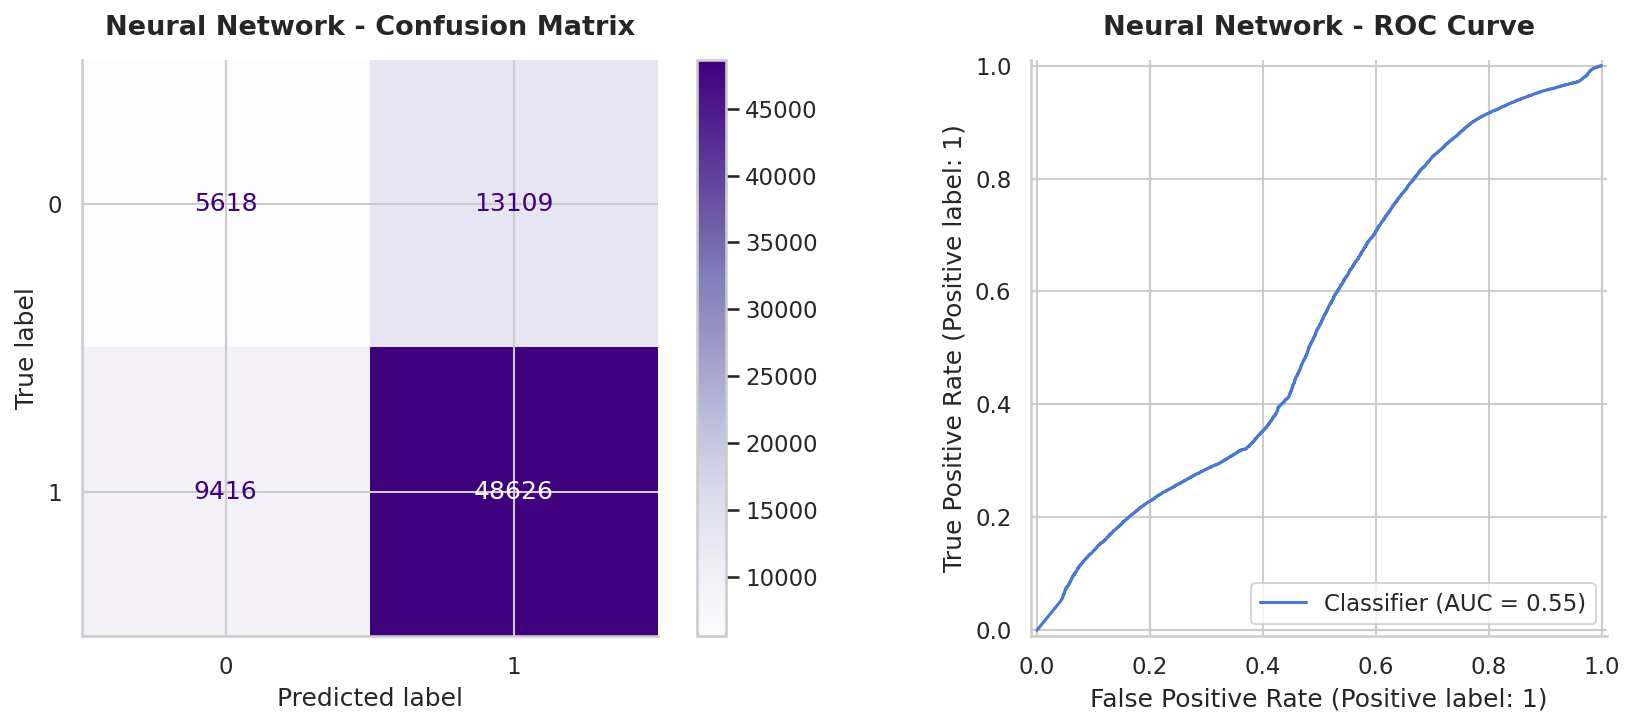

                     Accuracy  Precision    Recall  F1-Score   AUC-ROC
Logistic Regression  0.729370   0.821248  0.820682  0.820964  0.701359
Decision Tree        0.580091   0.824898  0.564419  0.670240  0.596314
SVM                  0.628118   0.862153  0.604838  0.710928  0.707563
Neural Network       0.706587   0.787657  0.837773  0.811942  0.545946


'/content/drive/MyDrive/team_data/08c_nn.png'

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import shutil

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

# =========================
# Background color
# =========================
BG = '#F8F9FB'

# =========================
# Scale data
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# =========================
# Apply SMOTE AFTER scaling
# =========================
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(
    X_train_scaled,
    y_train
)

# =========================
# Neural Network Model
# =========================
nn = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=32,
    learning_rate='adaptive',
    max_iter=300,
    early_stopping=True,
    random_state=42
)

# =========================
# Train
# =========================
nn.fit(X_train_sm, y_train_sm)

# =========================
# Prediction
# =========================
y_pred_nn  = nn.predict(X_test_scaled)
y_proba_nn = nn.predict_proba(X_test_scaled)[:, 1]

# =========================
# Metrics
# =========================
metrics_nn = {
    'Accuracy' : accuracy_score(y_test, y_pred_nn),
    'Precision': precision_score(y_test, y_pred_nn, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_nn),
    'F1-Score' : f1_score(y_test, y_pred_nn),
    'AUC-ROC'  : roc_auc_score(y_test, y_proba_nn),
}

print('=' * 45)
print('  NEURAL NETWORK')
print('=' * 45)

for k, v in metrics_nn.items():
    print(f'{k:<12}: {v:.4f}')

print()

print(classification_report(
    y_test,
    y_pred_nn,
    target_names=['Not Liked', 'Liked']
))

# =========================
# Visualization
# =========================
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nn,
    cmap='Purples',
    ax=ax[0]
)

ax[0].set_title('Neural Network - Confusion Matrix')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_proba_nn,
    ax=ax[1]
)

ax[1].set_title('Neural Network - ROC Curve')

plt.tight_layout()

# Save figure BEFORE show
plt.savefig(
    '/content/08c_nn.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=BG
)

plt.show()

# =========================
# Comparison Table
# =========================
comparison_df = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'Decision Tree'      : metrics_dt,
    'SVM'                : metrics_svm,
    'Neural Network'     : metrics_nn,
}).T

print(comparison_df)

# =========================
# Copy image
# =========================
shutil.copy(
    '/content/08c_nn.png',
    DATA_PATH + '08c_nn.png'
)

Model Comparison

  MODEL COMPARISON SUMMARY
                                Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression (Baseline)    0.7294     0.8212  0.8207    0.8210   0.7014
Decision Tree                     0.5801     0.8249  0.5644    0.6702   0.5963
SVM                               0.6281     0.8622  0.6048    0.7109   0.7076
Neural Network                    0.7066     0.7877  0.8378    0.8119   0.5459

  Best model (F1-Score): Logistic Regression (Baseline) (0.8210)


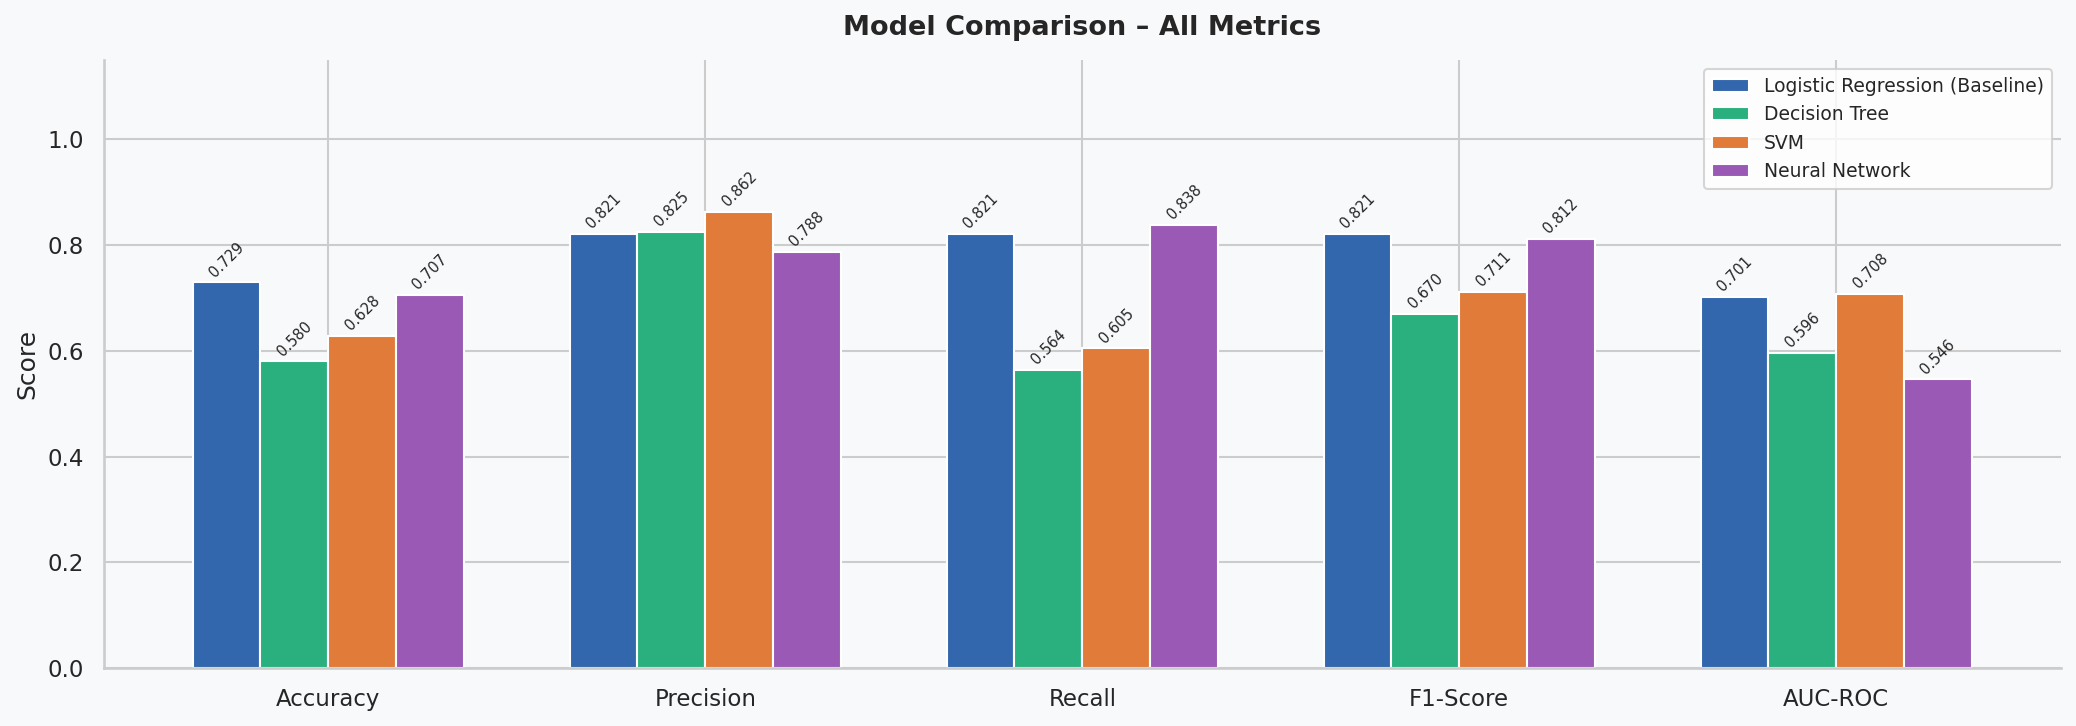


All model images saved to Drive!


In [40]:
# ── MODEL COMPARISON – tất cả 4 models ───────────────────────
summary = pd.DataFrame({
    'Logistic Regression (Baseline)': metrics_lr,
    'Decision Tree'                 : metrics_dt,
    'SVM'                           : metrics_svm,
    'Neural Network'                : metrics_nn,   # ← thêm vào
}).T.round(4)

print("=" * 65)
print("  MODEL COMPARISON SUMMARY")
print("=" * 65)
print(summary.to_string())

# Highlight best model
best_model = summary['F1-Score'].idxmax()
print(f"\n  Best model (F1-Score): {best_model} ({summary.loc[best_model, 'F1-Score']:.4f})")

# Visualize comparison
BG = '#F8F9FB'
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)

x      = np.arange(len(summary.columns))
w      = 0.18
colors = ['#3266AD', '#2AAF7F', '#E07B39', '#9B59B6']  # 4 màu cho 4 models

for i, (model, color) in enumerate(zip(summary.index, colors)):
    bars = ax.bar(x + i * w, summary.loc[model], width=w,
                  label=model, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(summary.columns, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_facecolor(BG)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Model Comparison – All Metrics',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('11_model_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

shutil.copy('/content/11_model_comparison.png', DATA_PATH + '11_model_comparison.png')
print("\nAll model images saved to Drive!")

EVALUATION MODULE

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay,
)

BG = '#F8F9FB'

In [42]:
# ── Hàm tiện ích: tính metrics cho bất kỳ model ──────────────
def compute_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred),
        'F1-Score' : f1_score(y_true, y_pred),
        'AUC-ROC'  : roc_auc_score(y_true, y_proba),
    }

# ── Tính metrics cho tất cả models ───────────────────────────
metrics_lr  = compute_metrics(y_test, y_pred_lr,  y_proba_lr)
metrics_dt  = compute_metrics(y_test, y_pred_dt,  y_proba_dt)
metrics_svm = compute_metrics(y_test, y_pred_svm, y_proba_svm)

metrics_dict = {
    'Logistic Regression': metrics_lr,
    'Decision Tree'      : metrics_dt,
    'SVM'                : metrics_svm,
}

print("Done — metrics_dict sẵn sàng cho evaluation.")

Done — metrics_dict sẵn sàng cho evaluation.


In [43]:
# ── METRICS COMPARISON TABLE ──
def plot_metrics_comparison(metrics_dict: dict):
    """
    metrics_dict = {
        'Logistic Regression': metrics_lr,
        'Decision Tree'      : metrics_dt,
        'XGBoost'            : metrics_xgb,
    }
    """
    summary = pd.DataFrame(metrics_dict).T.round(4)

    print("=" * 65)
    print("  MODEL COMPARISON SUMMARY")
    print("=" * 65)
    print(summary.to_string())

    colors = ['#3266AD', '#2AAF7F', '#E07B39', '#9B59B6']
    x = np.arange(len(summary.columns))
    w = 0.18

    fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
    ax.set_facecolor(BG)

    for i, (model, color) in enumerate(zip(summary.index, colors)):
        bars = ax.bar(x + i * w, summary.loc[model], width=w,
                      label=model, color=color, edgecolor='white')
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_xticks(x + w * 1.5)
    ax.set_xticklabels(summary.columns, fontsize=11)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.15)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_title('Model Comparison – All Metrics',
                 fontsize=13, fontweight='bold', pad=12)

    plt.tight_layout()
    plt.savefig('A1_metrics_comparison.png', dpi=150,
                bbox_inches='tight', facecolor=BG)
    plt.show()
    return summary

In [44]:
# ── ALL CONFUSION MATRICES (2×2 grid) ──
def plot_all_confusion_matrices(y_test, preds_dict: dict):
    """
    preds_dict = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree'      : y_pred_dt,
    'XGBoost'            : y_pred_xgb,
    'SVM'                : y_pred_svm,
    }
    """
    cmaps   = ['Blues', 'Greens', 'Oranges', 'Purples']
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor=BG)
    axes = axes.flatten()

    for ax, (name, y_pred), cmap in zip(axes, preds_dict.items(), cmaps):
        ConfusionMatrixDisplay(
            confusion_matrix(y_test, y_pred),
            display_labels=['Not Liked', 'Liked']
        ).plot(ax=ax, colorbar=False, cmap=cmap)
        ax.set_title(f'{name}', fontweight='bold')
        ax.set_facecolor(BG)

    plt.suptitle('Confusion Matrices – All Models',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('A2_confusion_matrices.png', dpi=150,
                bbox_inches='tight', facecolor=BG)
    plt.show()

In [45]:
# ── ALL ROC CURVES (trên 1 đồ thị) ──
def plot_combined_roc(y_test, probas_dict: dict):
    """
    probas_dict = {
        'Logistic Regression (AUC=...)': y_proba_lr,
        'Decision Tree (AUC=...)'      : y_proba_dt,
        'XGBoost (AUC=...)'            : y_proba_xgb,
    }
    Gợi ý: build dict sau khi có metrics:
        probas_dict = {
            f'Logistic Regression (AUC={metrics_lr[\"AUC-ROC\"]:.3f})': y_proba_lr,
            ...
        }
    """
    colors = ['#3266AD', '#2AAF7F', '#E07B39', '#9B59B6']
    fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
    ax.set_facecolor(BG)

    for (name, y_proba), color in zip(probas_dict.items(), colors):
        RocCurveDisplay.from_predictions(
            y_test, y_proba,
            name=name, ax=ax, color=color
        )

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    ax.set_title('ROC Curves – All Models',
                 fontsize=13, fontweight='bold', pad=12)
    ax.legend(loc='lower right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig('A3_roc_combined.png', dpi=150,
                bbox_inches='tight', facecolor=BG)
    plt.show()

FEATURE IMPORTANCE

In [46]:
# ── Feature Importance cho XGBoost ──
def plot_feature_importance_xgb(feature_names, xgb_model):

    feat_imp = pd.Series(
        xgb_model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    ax.set_facecolor(BG)

    bars = ax.barh(
        feat_imp.index,
        feat_imp.values,
    )

    ax.set_title(
        'XGBoost – Feature Importance',
        fontweight='bold',
        fontsize=12
    )

    ax.set_xlabel('Importance Score')
    ax.spines[['top', 'right']].set_visible(False)

    for bar in bars:
        ax.text(
            bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}',
            va='center'
        )

    plt.tight_layout()
    plt.savefig(
        'B1_feature_importance_xgb.png',
        dpi=150,
        bbox_inches='tight',
        facecolor=BG
    )

    plt.show()

In [47]:
# ── Logistic Regression coefficients ─────
def plot_lr_coefficients(lr_model, feature_names: list):
    """
    lr_model = lr  (fitted LogisticRegression)
    """
    coef = pd.Series(lr_model.coef_[0], index=feature_names).sort_values()
    colors = ['#E74C3C' if v < 0 else '#2AAF7F' for v in coef]

    fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
    ax.set_facecolor(BG)
    bars = ax.barh(coef.index, coef.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Logistic Regression – Feature Coefficients',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Coefficient Value')
    ax.spines[['top', 'right']].set_visible(False)

    for bar in bars:
        val = bar.get_width()
        x   = val + 0.01 if val >= 0 else val - 0.01
        ha  = 'left' if val >= 0 else 'right'
        ax.text(x, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha=ha, fontsize=9)

    legend_elems = [
        mpatches.Patch(facecolor='#2AAF7F', label='Positive (→ Liked)'),
        mpatches.Patch(facecolor='#E74C3C', label='Negative (→ Not Liked)'),
    ]
    ax.legend(handles=legend_elems, fontsize=9, frameon=False)

    plt.tight_layout()
    plt.savefig('B2_lr_coefficients.png', dpi=150,
                bbox_inches='tight', facecolor=BG)
    plt.show()

In [48]:
# ── Compare Feature Importance: XGBoost vs Logistic Regression ──
def plot_feature_importance_comparison(
    feature_names,
    xgb_model,
    lr_model
):

    xgb_imp = pd.Series(
        xgb_model.feature_importances_,
        index=feature_names
    )

    lr_imp = pd.Series(
        np.abs(lr_model.coef_[0]),
        index=feature_names
    )

    def norm(s):
        return (s - s.min()) / (s.max() - s.min() + 1e-9)

    df_imp = pd.DataFrame({
        'XGBoost'      : norm(xgb_imp),
        'Logistic Reg.': norm(lr_imp),
    }).sort_values('XGBoost', ascending=True)

    x = np.arange(len(df_imp))
    w = 0.35

    fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
    ax.set_facecolor(BG)

    for i, col in enumerate(df_imp.columns):
        ax.barh(
            x + i*w,
            df_imp[col],
            height=w,
            label=col
        )

    ax.set_yticks(x + w/2)
    ax.set_yticklabels(df_imp.index)

    ax.set_xlabel('Normalised Importance Score')
    ax.set_title(
        'Feature Importance Comparison',
        fontsize=13,
        fontweight='bold'
    )

    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(
        'B3_feature_importance_comparison.png',
        dpi=150,
        bbox_inches='tight',
        facecolor=BG
    )

    plt.show()

FULL EVALUATION PIPELINE

In [49]:
def run_full_evaluation(
    y_test,
    FEATURE_COLS,
    # Models
    lr_model, rf_model, xgb_model,
    # Predictions
    y_pred_lr,  y_proba_lr,
    y_pred_dt,  y_proba_dt,
    y_pred_rf,  y_proba_rf,
    y_pred_xgb, y_proba_xgb,
    # Optional
    save_to_drive=True,
    DATA_PATH='/content/drive/MyDrive/team_data/',
):
    import shutil

    print("\n" + "=" * 65)
    print("  FULL EVALUATION PIPELINE")
    print("=" * 65 + "\n")

    # ---- 1. Build metrics ----
    metrics_lr  = compute_metrics(y_test, y_pred_lr,  y_proba_lr)
    metrics_dt  = compute_metrics(y_test, y_pred_dt,  y_proba_dt)
    metrics_rf  = compute_metrics(y_test, y_pred_rf,  y_proba_rf)
    metrics_xgb = compute_metrics(y_test, y_pred_xgb, y_proba_xgb)

    metrics_dict = {
        'Logistic Regression': metrics_lr,
        'Decision Tree'      : metrics_dt,
        'XGBoost'            : metrics_xgb,
    }

# ---- 2. Metrics comparison ----
    summary = plot_metrics_comparison(metrics_dict)

    # ---- 3. Confusion matrices ----
    plot_all_confusion_matrices(y_test, {
        'Logistic Regression': y_pred_lr,
        'Decision Tree'      : y_pred_dt,
        'XGBoost'            : y_pred_xgb,
    })

# ---- 4. Combined ROC curve ----
    probas_dict = {
        f'Logistic Regression (AUC={metrics_lr["AUC-ROC"]:.3f})'  : y_proba_lr,
        f'Decision Tree       (AUC={metrics_dt["AUC-ROC"]:.3f})'  : y_proba_dt,
        f'XGBoost             (AUC={metrics_xgb["AUC-ROC"]:.3f})' : y_proba_xgb,
    }
    plot_combined_roc(y_test, probas_dict)

# ---- 5. Feature importance ----
    plot_feature_importance_trees(FEATURE_COLS, rf_model, xgb_model)
    plot_lr_coefficients(lr_model, FEATURE_COLS)
    plot_feature_importance_comparison(FEATURE_COLS, rf_model, xgb_model, lr_model)

    # ---- 6. Best model summary ----
    best_name = summary['F1-Score'].idxmax()
    print("\n" + "=" * 45)
    print(f"  BEST MODEL (by F1): {best_name}")
    print("=" * 45)
    for k, v in metrics_dict[best_name].items():
        print(f"  {k:<12}: {v:.4f}")

   # ---- 7. Save to Drive ----
    if save_to_drive:
        images = [
            'A1_metrics_comparison.png',
            'A2_confusion_matrices.png',
            'A3_roc_combined.png',
            'B1_feature_importance_trees.png',
            'B2_lr_coefficients.png',
            'B3_feature_importance_comparison.png',
        ]
        for img in images:
            try:
                shutil.copy(f'/content/{img}', DATA_PATH + img)
                print(f"  Saved: {img}")
            except Exception as e:
                print(f"  Warning: could not save {img} — {e}")

    print("\nFull evaluation complete!")
    return summary, metrics_dict

  MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.7294     0.8212  0.8207    0.8210   0.7014
Decision Tree          0.5801     0.8249  0.5644    0.6702   0.5963
SVM                    0.6281     0.8622  0.6048    0.7109   0.7076
Neural Network         0.7066     0.7877  0.8378    0.8119   0.5459


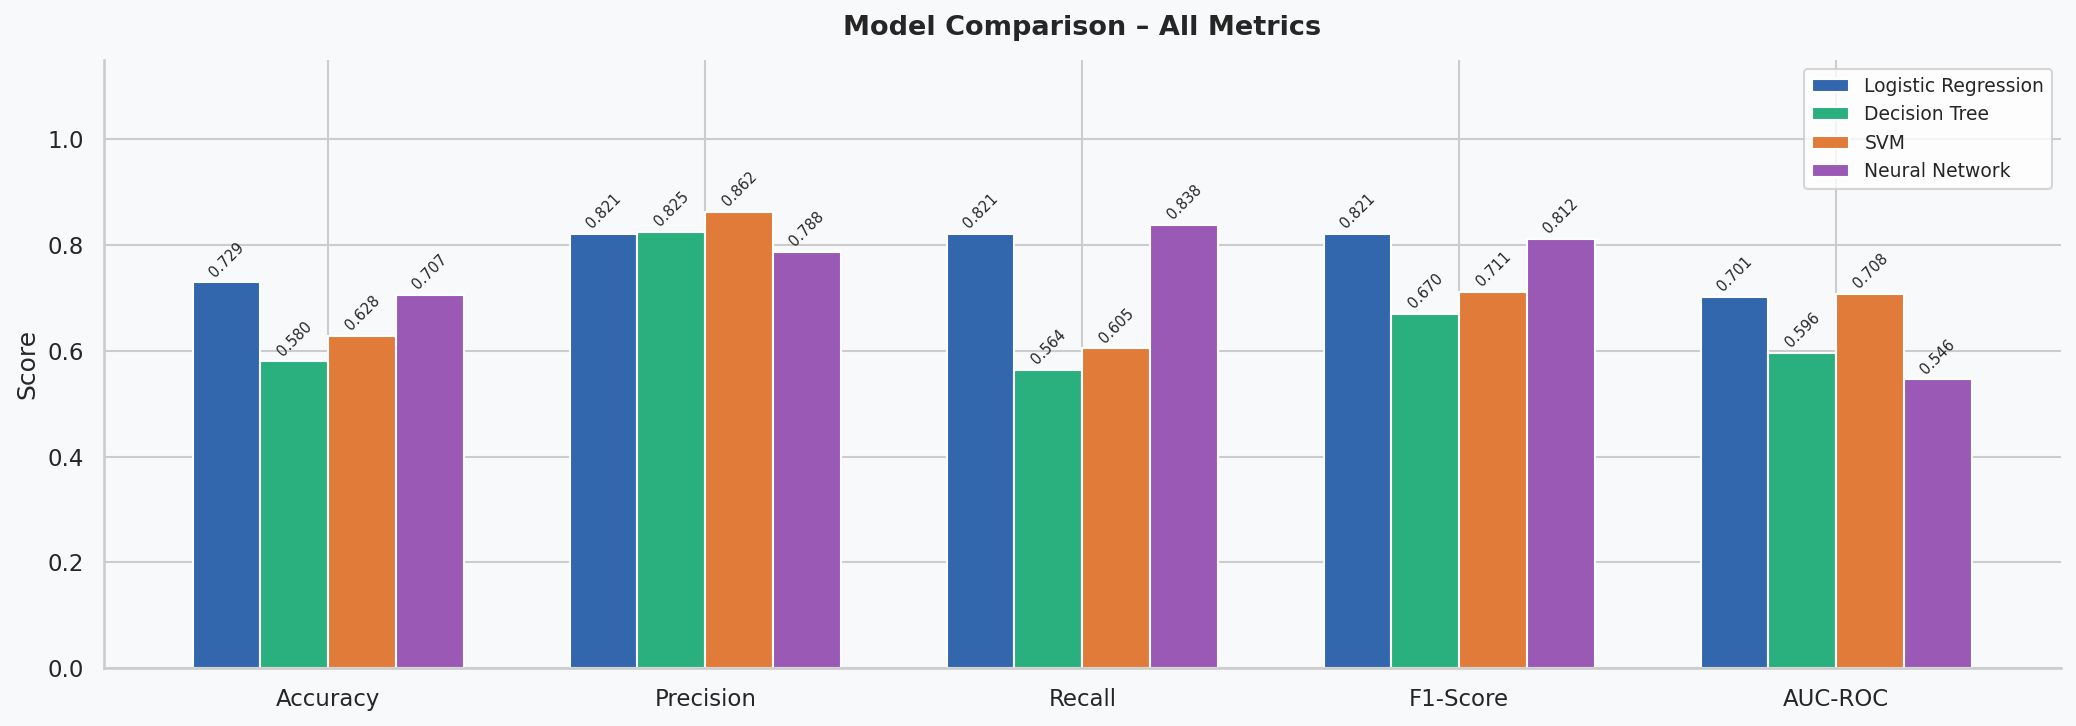

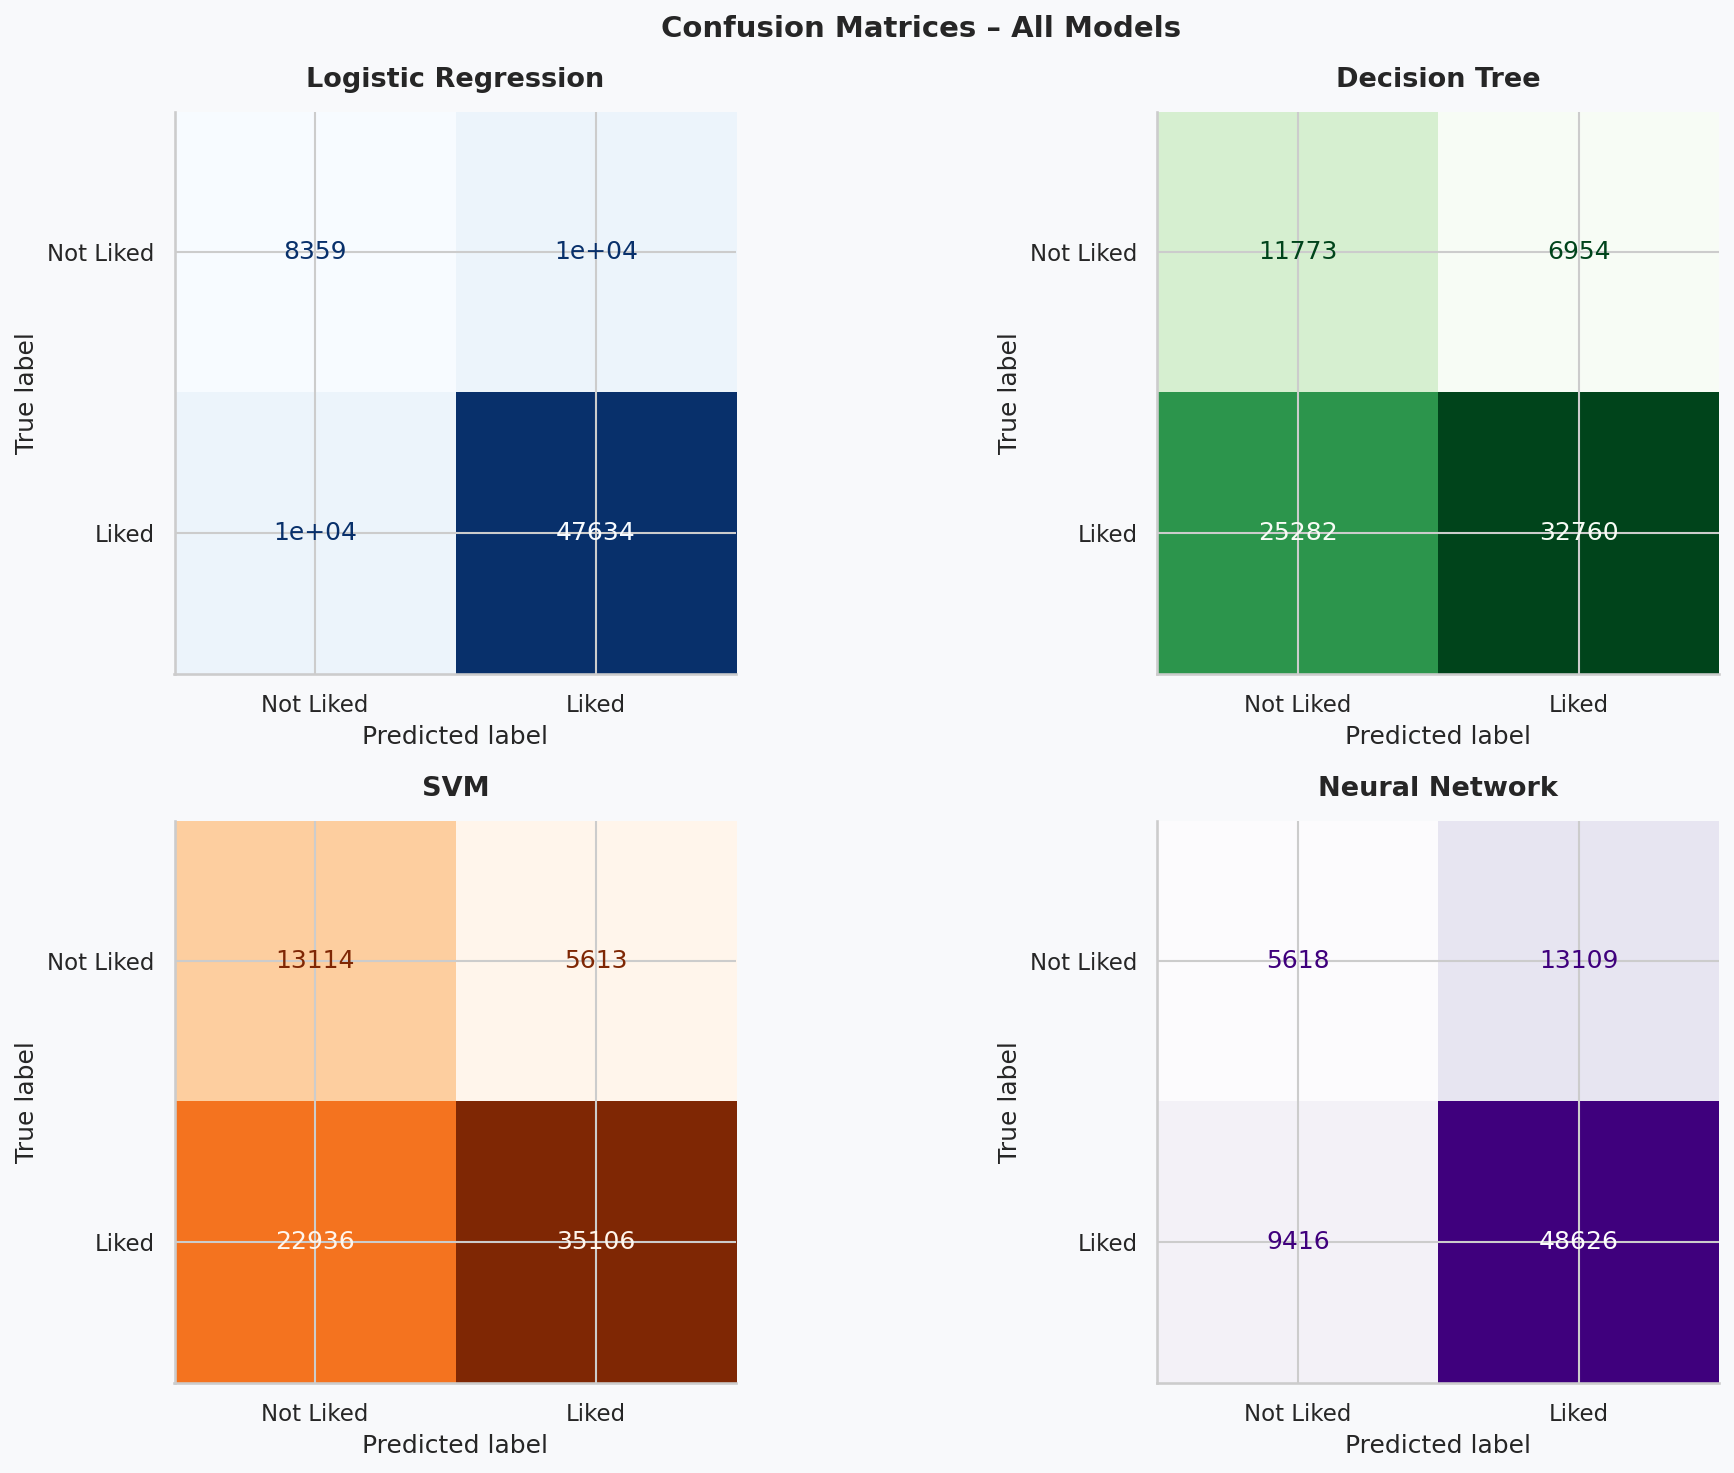

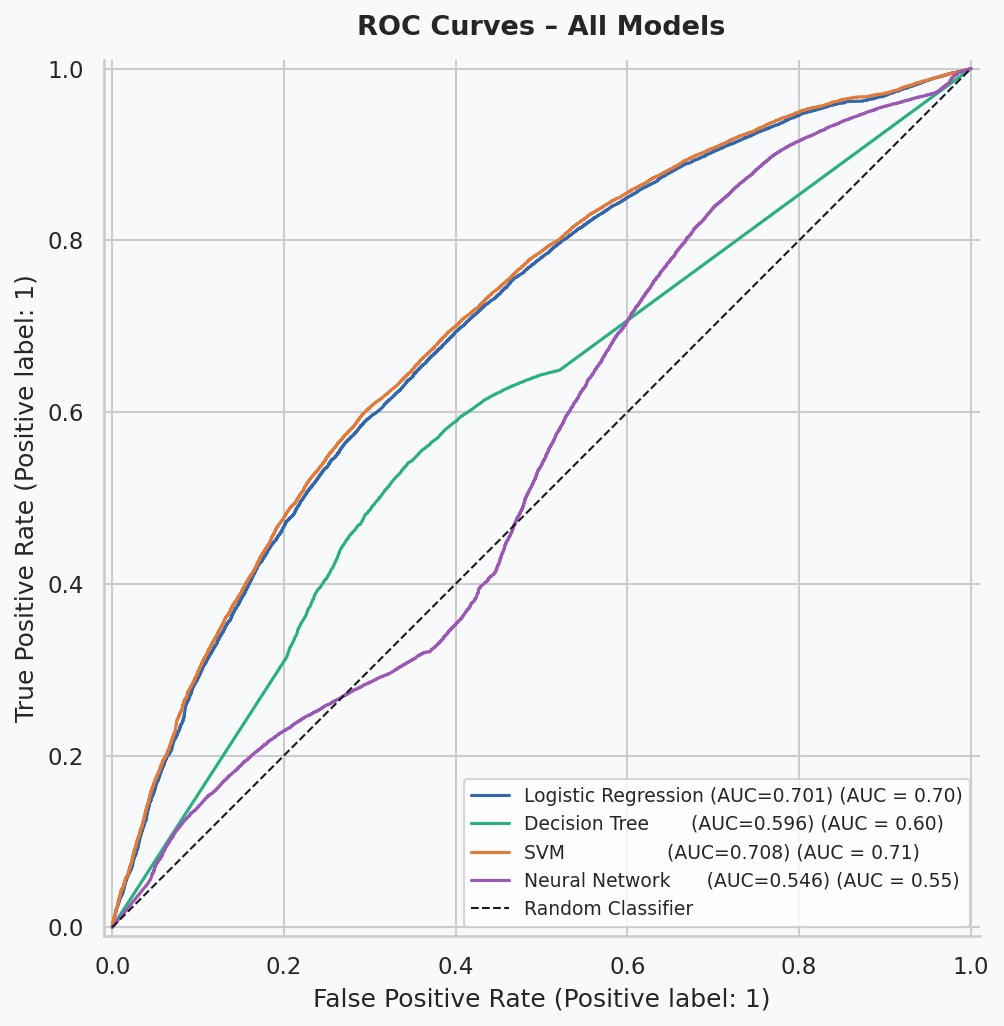

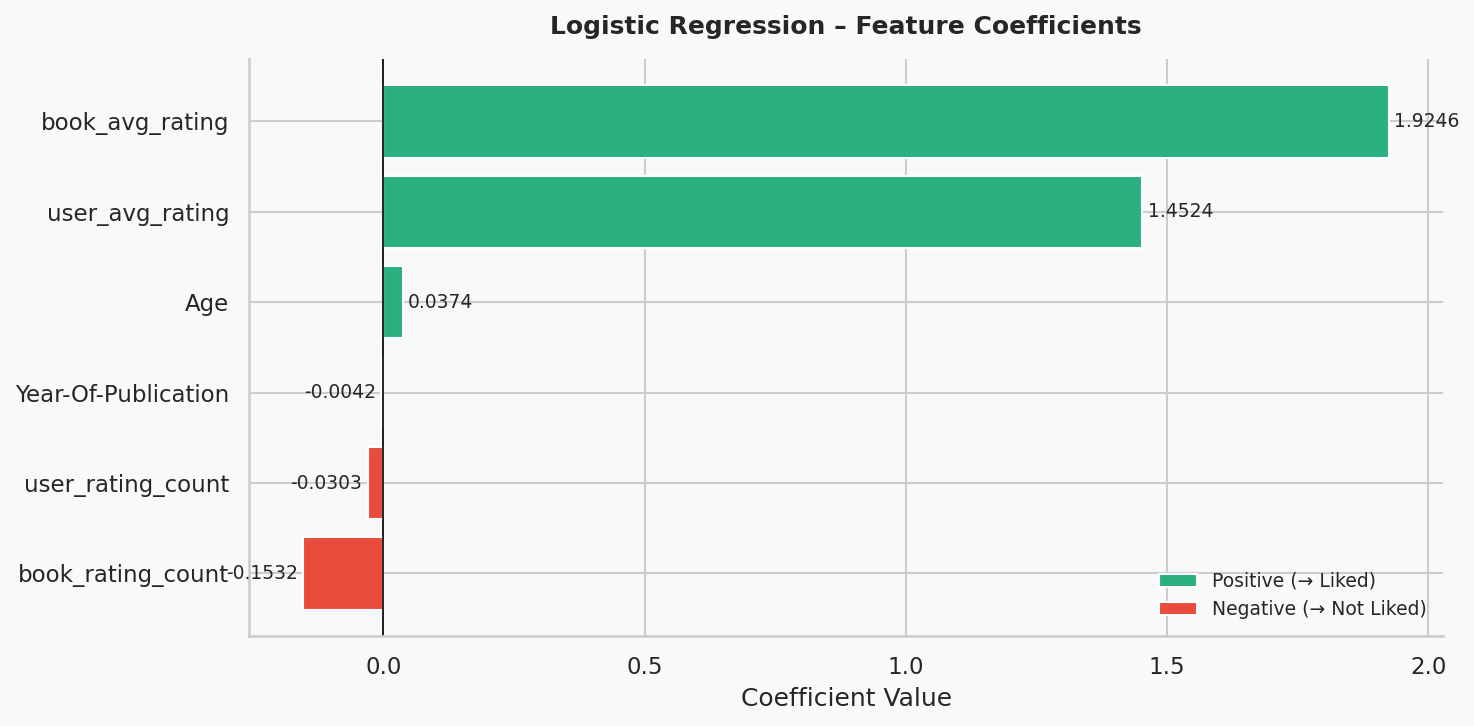

Saved: A1_metrics_comparison.png
Saved: A2_confusion_matrices.png
Saved: A3_roc_combined.png
Saved: B2_lr_coefficients.png


In [50]:
# ── GỌI CÁC HÀM EVALUATION ───────────────────────────────────

# 1. Metrics comparison (dùng lại summary ở trên)
plot_metrics_comparison({
    'Logistic Regression': metrics_lr,
    'Decision Tree'      : metrics_dt,
    'SVM'                : metrics_svm,
    'Neural Network'     : metrics_nn,
})

# 2. All confusion matrices
plot_all_confusion_matrices(y_test, {
    'Logistic Regression': y_pred_lr,
    'Decision Tree'      : y_pred_dt,
    'SVM'                : y_pred_svm,
    'Neural Network'     : y_pred_nn,
})

# 3. Combined ROC curve
plot_combined_roc(y_test, {
    f'Logistic Regression (AUC={metrics_lr["AUC-ROC"]:.3f})' : y_proba_lr,
    f'Decision Tree       (AUC={metrics_dt["AUC-ROC"]:.3f})' : y_proba_dt,
    f'SVM                 (AUC={metrics_svm["AUC-ROC"]:.3f})': y_proba_svm,
    f'Neural Network      (AUC={metrics_nn["AUC-ROC"]:.3f})' : y_proba_nn,
})

# 4. LR Coefficients (feature importance cho Logistic Regression)
plot_lr_coefficients(lr, FEATURE_COLS)

# Lưu vào Drive
for img in ['A1_metrics_comparison.png', 'A2_confusion_matrices.png',
            'A3_roc_combined.png', 'B2_lr_coefficients.png']:
    try:
        shutil.copy(f'/content/{img}', DATA_PATH + img)
        print(f"Saved: {img}")
    except Exception as e:
        print(f"Warning: {e}")